In [ ]:
import os
os.environ['R_HOME'] = '/datapool/home/zhijian/zhijian/miniconda3/envs/soybean_sam/lib/R'
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

In [ ]:
from joblib import Parallel, delayed
import os
os.environ['R_HOME'] = '/datapool/home/zhijian/zhijian/miniconda3/envs/soybean_sam/lib/R'
# os.environ['R_HOME'] = '/public/home/liuzj/softwares/anaconda3/envs/hormone/lib/R'
import rpy2
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
import rpy2.ipython.html
rpy2.ipython.html.init_printing()
from jpy_tools.rTools import py2r, r2py, r_inline_plot, rHelp, trl, rSet, rGet, ad2so, so2ad, so2md, rcontext, Trl, r2py_re, py2r_re, RR, FR
from jpy_tools import loadPkl, toPkl
rBase = importr('base')
rUtils = importr('utils')
dplyr = importr('dplyr')
reticulate = importr('reticulate')
R = ro.r
T = Trl()
R("options(browser='firefox', shiny.port=6533, max.print=200)")
%load_ext rpy2.ipython


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

<Figure size 100x100 with 0 Axes>

In [ ]:
import scanpy as sc
import muon as mu
import pandas as pd
import numpy as np
import scipy.sparse as ss
from tqdm import tqdm
from loguru import logger
from functools import partial
from jpy_tools import singleCellTools

In [ ]:
%config InlineBackend.figure_format = 'retina'
import seaborn as sns
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.font_manager as font_manager
import marsilea as ma
import marsilea.plotter as mp
# plt.rcParams['figure.dpi'] = 150
font_dirs = ["/datapool/home/zhijian/.local/share/mpl_fontkit/"]
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
plt.rcParams["font.family"] = "Arial"
sns.despine(top=True, right=True)
from itertools import product
from functools import reduce
import patchworklib as pw
from jpy_tools.otherTools import pwRecoverSeaborn, pwStack, F, pwShow
pw.show = pwShow
fc_recoverSns = pwRecoverSeaborn()
import seaborn.objects as so
from cycler import cycler
dt_snsStyle = {**sns.axes_style('ticks'), "legend.frameon": False, "axes.spines.top":False, "axes.spines.right":False, "axes.prop_cycle":cycler(color=['grey'])}
so.Plot.config.theme.update(dt_snsStyle)
from jpy_tools.soExt import Axhline, Axvline, mvLegToAx
from jpy_tools import soExt
plt.set_loglevel('Warning')

<Figure size 640x480 with 0 Axes>

In [ ]:
from functools import partial

In [ ]:
dir_result = '/datapool/home/zhijian/projects/hormone/analysis/'

# load myb60 data

2026-05-15 12:39:24.566 | WARNING  | jpy_tools.singleCellTools:__init__:558 - The index of ad.obs contains '_' which may cause some problems, please remove it first
2026-05-15 12:39:24.576 | WARNING  | jpy_tools.singleCellTools:rawLayer:611 - rawLayer will be overwritten by raw and all the related objects will be re-initialized
2026-05-15 12:39:42 - WARNING - R[write to console]: 611 genes passed tf-idf cut-off and 279 soup quantile filter.  Taking the top 100.

2026-05-15 12:39:42 - WARNING - R[write to console]: Using 839 independent estimates of rho.

2026-05-15 12:39:42 - WARNING - R[write to console]: Estimated global rho of 0.05

2026-05-15 12:39:43 - WARNING - R[write to console]: Expanding counts from 18 clusters to 5862 cells.



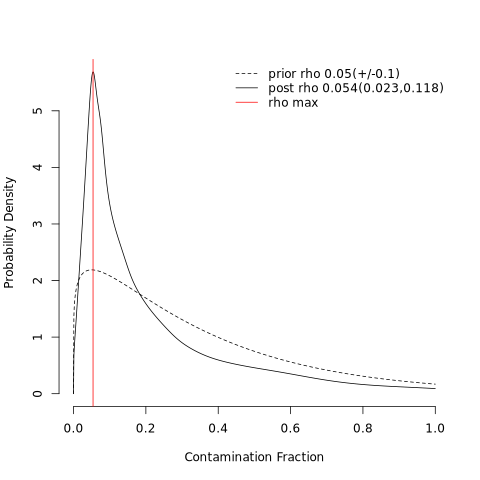

In [ ]:
ad_mutDmso = sc.read_10x_mtx("/datapool/data/Users/zhijian/projects/hormone/myb60_sc/res_187/s_187/outs/filter_matrix")
ad_mutDmso.layers['raw'] = ad_mutDmso.X.copy()
ad_mutDmsoRaw = sc.read_10x_mtx("/datapool/data/Users/zhijian/projects/hormone/myb60_sc/res_187/s_187/outs/raw_matrix")
ad_mutDmsoRaw.layers['raw'] = ad_mutDmsoRaw.X.copy()
ead_mutDmso = singleCellTools.EnhancedAnndata(ad_mutDmso)
ead_mutDmso.qc.removeAmbientBySoupx(ad_mutDmsoRaw)

In [ ]:
ad_mutDmsoRaw.obs['sumUmi'] = ad_mutDmsoRaw.X.sum(axis=1).A1

2026-05-15 12:40:06.103 | WARNING  | jpy_tools.singleCellTools:__init__:558 - The index of ad.obs contains '_' which may cause some problems, please remove it first
2026-05-15 12:40:06.111 | WARNING  | jpy_tools.singleCellTools:rawLayer:611 - rawLayer will be overwritten by raw and all the related objects will be re-initialized
2026-05-15 12:40:25 - WARNING - R[write to console]: 185 genes passed tf-idf cut-off and 114 soup quantile filter.  Taking the top 100.

2026-05-15 12:40:25 - WARNING - R[write to console]: Using 616 independent estimates of rho.

2026-05-15 12:40:25 - WARNING - R[write to console]: Estimated global rho of 0.06

2026-05-15 12:40:26 - WARNING - R[write to console]: Expanding counts from 15 clusters to 7376 cells.



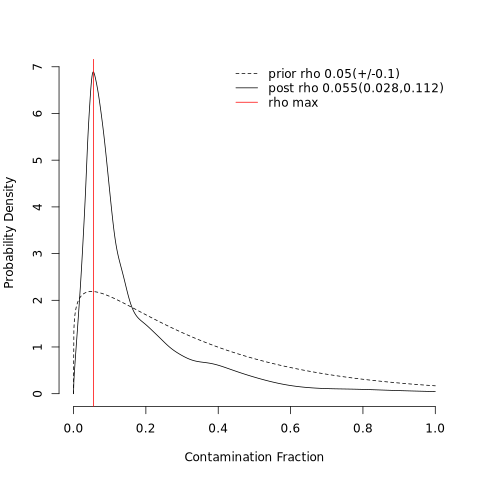

In [ ]:
ad_mutSa = sc.read_10x_mtx("/datapool/data/Users/zhijian/projects/hormone/myb60_sc/res_188/s_188/outs/filter_matrix")
ad_mutSa.layers['raw'] = ad_mutSa.X.copy()
ad_mutSaRaw = sc.read_10x_mtx("/datapool/data/Users/zhijian/projects/hormone/myb60_sc/res_188/s_188/outs/raw_matrix")
ad_mutSaRaw.layers['raw'] = ad_mutSaRaw.X.copy()
ead_mutSa = singleCellTools.EnhancedAnndata(ad_mutSa)
ead_mutSa.qc.removeAmbientBySoupx(ad_mutSaRaw)

In [ ]:
ead_mutDmso.obs.index = ead_mutDmso.obs.index.str.replace('_', "-")
ead_mutSa.obs.index = ead_mutSa.obs.index.str.replace('_', "-")


In [ ]:
ad_mutSaRaw.obs['sumUmi'] = ad_mutSaRaw.X.sum(axis=1).A1

In [ ]:
ad_mut = sc.concat(
    [
        ad_mutDmsoRaw[ad_mutDmsoRaw.obs.eval("sumUmi > 300")],
        ad_mutSaRaw[ad_mutSaRaw.obs.eval("sumUmi > 300")],
    ],
    axis=0,
    join="outer",
    label="myb60_group",
    keys=["mutDmso", "mutSa"],
    index_unique="-",
)

In [ ]:
ad_mut.obs.index = ad_mut.obs.index.str.replace('_', "-")

In [ ]:
ead_mut = singleCellTools.EnhancedAnndata(ad_mut)

2026-05-15 13:13:24.529 | WARNING  | jpy_tools.singleCellTools:rawLayer:611 - rawLayer will be overwritten by raw and all the related objects will be re-initialized


In [ ]:
ead_mut.norm.normBySct('myb60_group')

100%|██████████| 2/2 [00:00<00:00,  8.94it/s]



    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    
    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

R[write to console]: Warning:
R[write to console]:  Invalid name supplied, making object name syntactically valid. New object name is sumUmimyb60_groupX__group; see ?make.names for more details on syntax validity

R[write to console]: Warning:
R[write to console]:  Invalid name supplied, making object name syntactically valid. New object name is sumUmimyb60_groupX__group; see ?make.names for more details on syntax validity

R[write to console]: vst.flavor='v2' set. Using model with fixed slope and excluding poisson genes.

R[write to console]: vst.flavor='v2' set. Using model with fixed slope and excluding poisson genes.

R[write to console]: Calculating cell attributes from input UMI matrix: log_umi

R[write to console]: Calculating cell attributes from input UMI matrix: log_umi

R[write to console]: Total Step 1 genes: 16326

R[write to console]: Total overdispersed genes: 15662

R[write to console]: Excluding 664 genes from Step 1 because they are not overdispersed.

R[write to cons

  |                                                                      |   0%

R[write to console]: Variance stabilizing transformation of count matrix of size 18844 by 10923

R[write to console]: Model formula is y ~ log_umi

R[write to console]: Get Negative Binomial regression parameters per gene

R[write to console]: Using 2000 genes, 5000 cells



...

R[write to console]: Calculating gene attributes

R[write to console]: Calculating gene attributes

R[write to console]: Wall clock passed: Time difference of 35.29853 secs

R[write to console]: Determine variable features

R[write to console]: Centering data matrix

  |                                                                            
  |                                                                      |   0%
  |                                                                            
  |==================                                                    |  25%
  |                                                                            
  |===================================                                   |  50%
  |                                                                            
  |====================================================                  |  75%
  |                                                                            
  |=========

  |======================================================================| 100%


 50%|█████     | 1/2 [00:15<00:15, 15.11s/it]2026-05-15 13:16:17 - WARNING - R[write to console]: Setting min_variance based on median UMI:  0.04

2026-05-15 13:16:17 - WARNING - R[write to console]: Calculating residuals of type pearson for 3000 genes



  |======================================================================| 100%


100%|██████████| 2/2 [00:30<00:00, 15.12s/it]


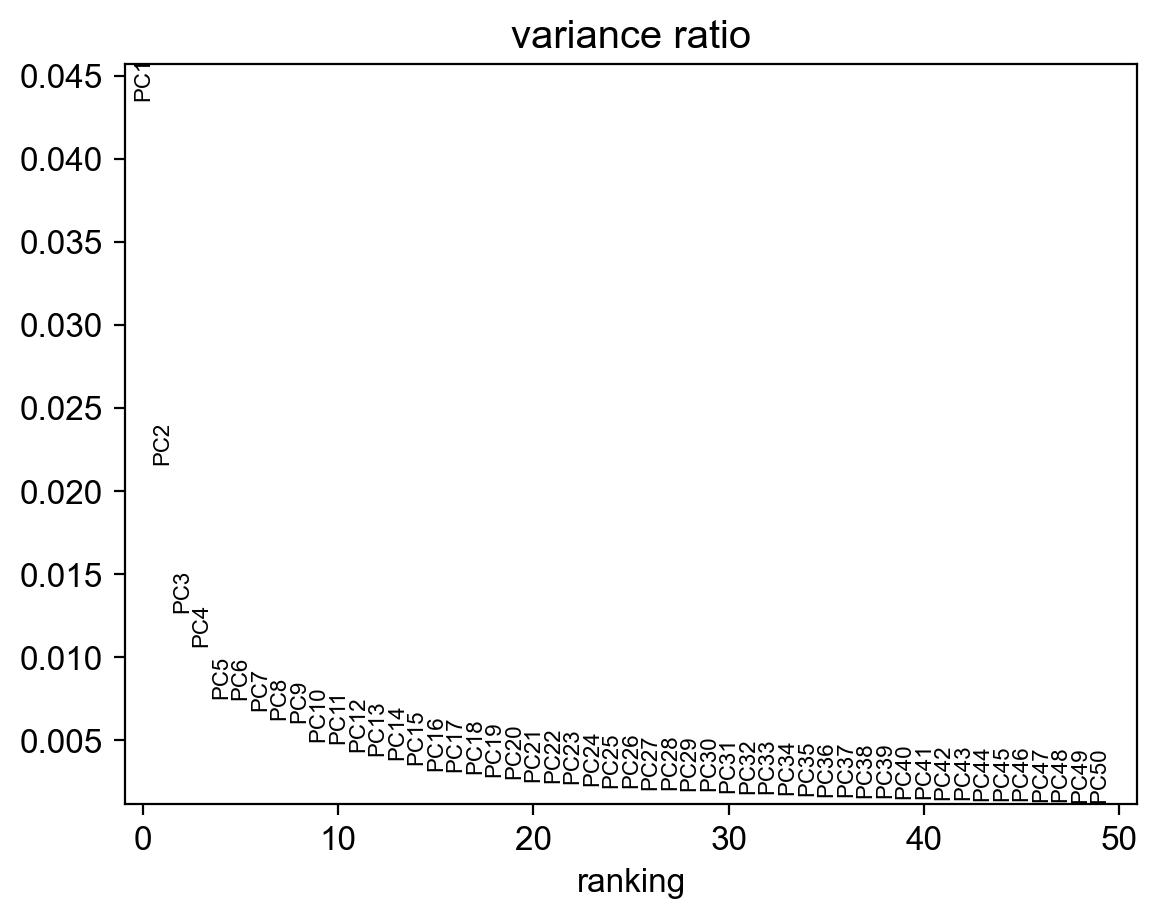

In [ ]:
sc.pl.pca_variance_ratio(ead_mut.ad, 50)

In [ ]:
sc.pp.neighbors(ead_mut.ad, use_rep='X_pca')

In [ ]:
sc.tl.umap(ead_mut.ad, 0.3)

2026-05-15 13:16:54.705 | DEBUG    | jpy_tools.singleCellTools.plotting:_embedding:1601 - ls_color: Index(['mutDmso', 'mutSa'], dtype='object')
2026-05-15 13:16:55.376 | INFO     | jpy_tools.singleCellTools.plotting:_embedding:1747 - Title location: 0.8938888888888888


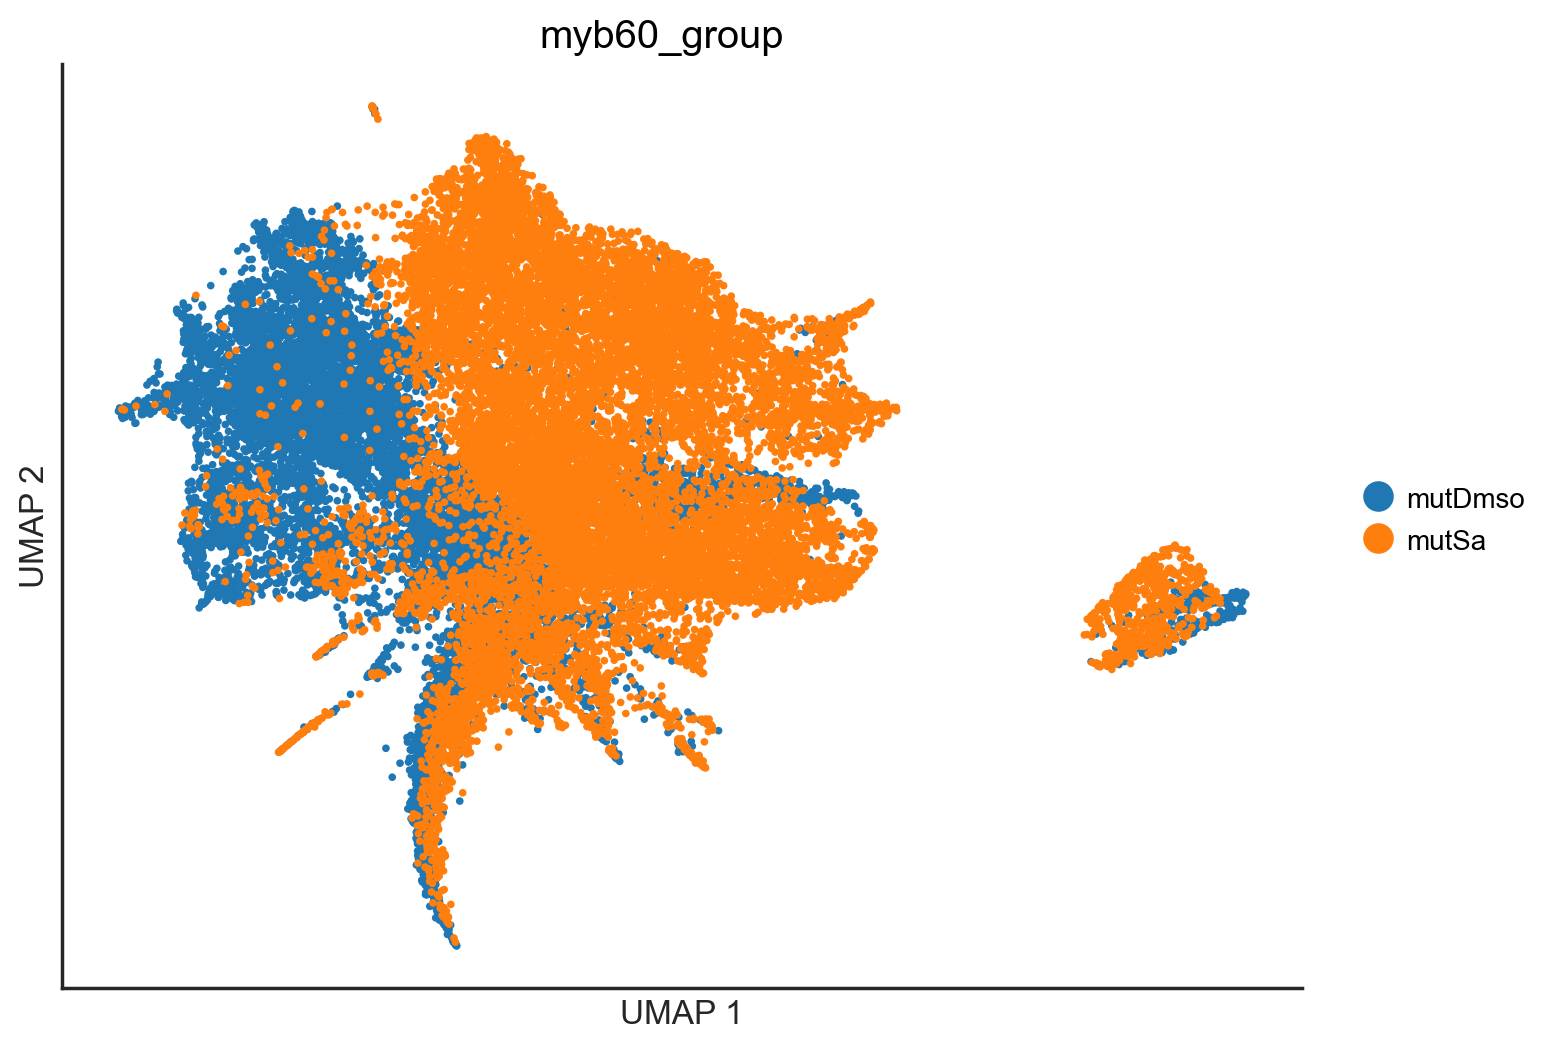

In [ ]:
ead_mut.pl.embedding(color='myb60_group', )

In [ ]:
import scanpy.external as sce
sce.pp.harmony_integrate(ead_mut.ad, 'myb60_group')
sc.pp.neighbors(ead_mut.ad, use_rep='X_pca_harmony')
sc.tl.umap(ead_mut.ad, 0.3)

2026-05-15 13:17:04,400 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-15 13:17:04 - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-15 13:17:04 - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-15 13:17:06,496 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-05-15 13:17:06 - INFO - sklearn.KMeans initialization complete.
2026-05-15 13:17:06,567 - harmonypy - INFO - Iteration 1 of 10
2026-05-15 13:17:06 - INFO - Iteration 1 of 10
2026-05-15 13:17:10,261 - harmonypy - INFO - Iteration 2 of 10
2026-05-15 13:17:10 - INFO - Iteration 2 of 10
2026-05-15 13:17:14,311 - harmonypy - INFO - Iteration 3 of 10
2026-05-15 13:17:14 - INFO - Iteration 3 of 10
2026-05-15 13:17:18,205 - harmonypy - INFO - Iteration 4 of 10
2026-05-15 13:17:18 - INFO - Iteration 4 of 10
2026-05-15 13:17:21,823 - harmonypy - INFO - Iteration 5 of 10
2026-05-15 13:17:21 - INFO - Iteration 5 of 10
2026-05-15 13:17:25,419 - harmonypy - IN

2026-05-15 13:18:14.353 | DEBUG    | jpy_tools.singleCellTools.plotting:_embedding:1601 - ls_color: Index(['mutDmso', 'mutSa'], dtype='object')
2026-05-15 13:18:15.023 | INFO     | jpy_tools.singleCellTools.plotting:_embedding:1747 - Title location: 0.8938888888888888


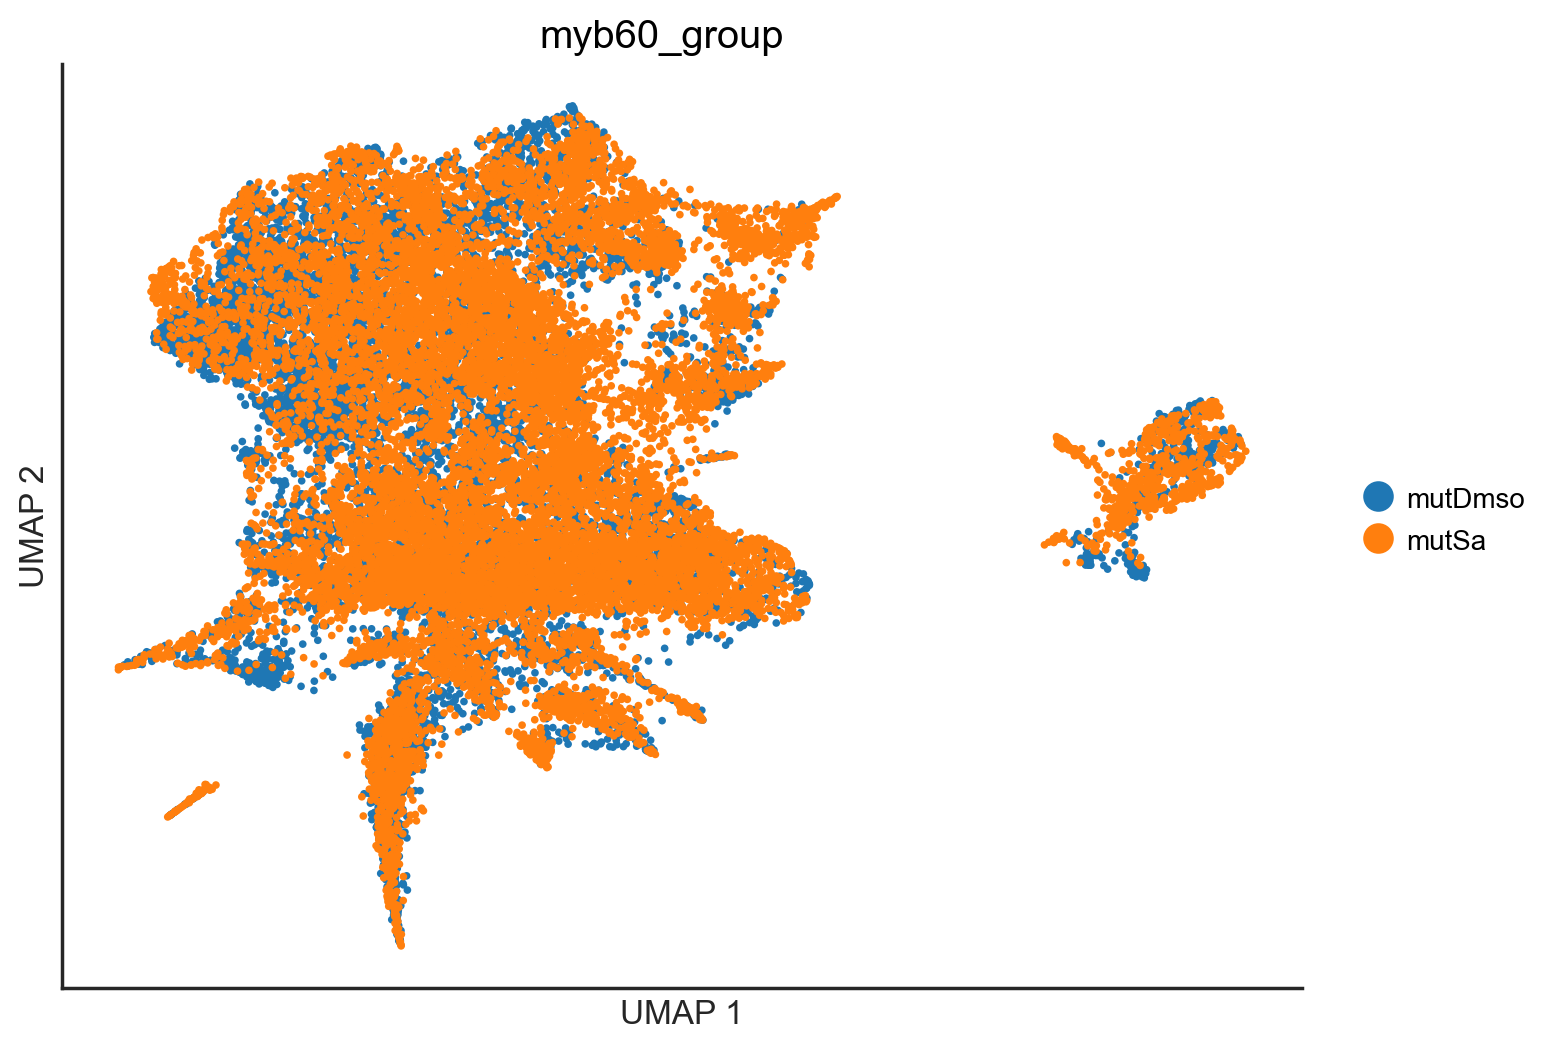

In [ ]:
ead_mut.pl.embedding(color='myb60_group', )

In [ ]:
ead_mut.initLayer()

In [ ]:
ead_mut.X = ead_mut.layers['normalize_log'].copy()

2026-05-15 13:18:16.683 | INFO     | jpy_tools.singleCellTools.plotting:_embedding:1747 - Title location: 0.9844444444444445


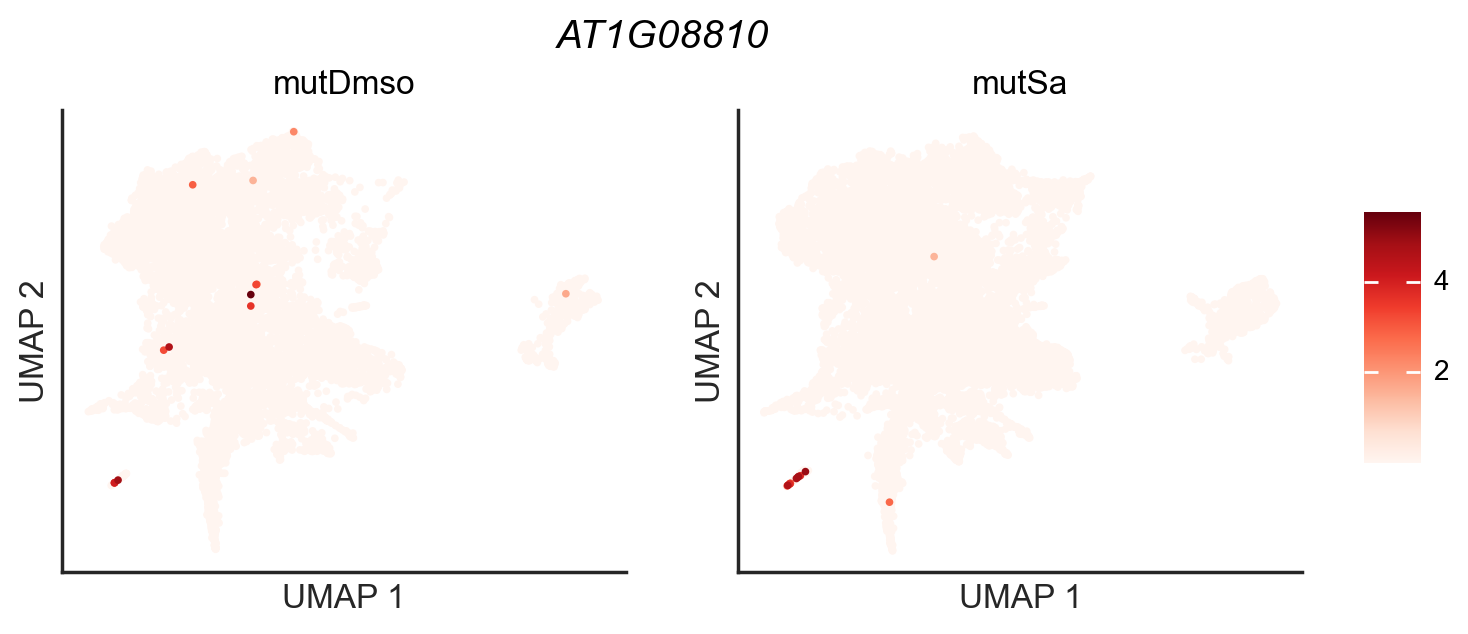

In [ ]:
ead_mut.pl.embedding(color='AT1G08810', groupby='myb60_group', figsize=(8,3))

2026-05-15 15:44:29.955 | INFO     | jpy_tools.singleCellTools.plotting:_embedding:1747 - Title location: 0.9008333333333333


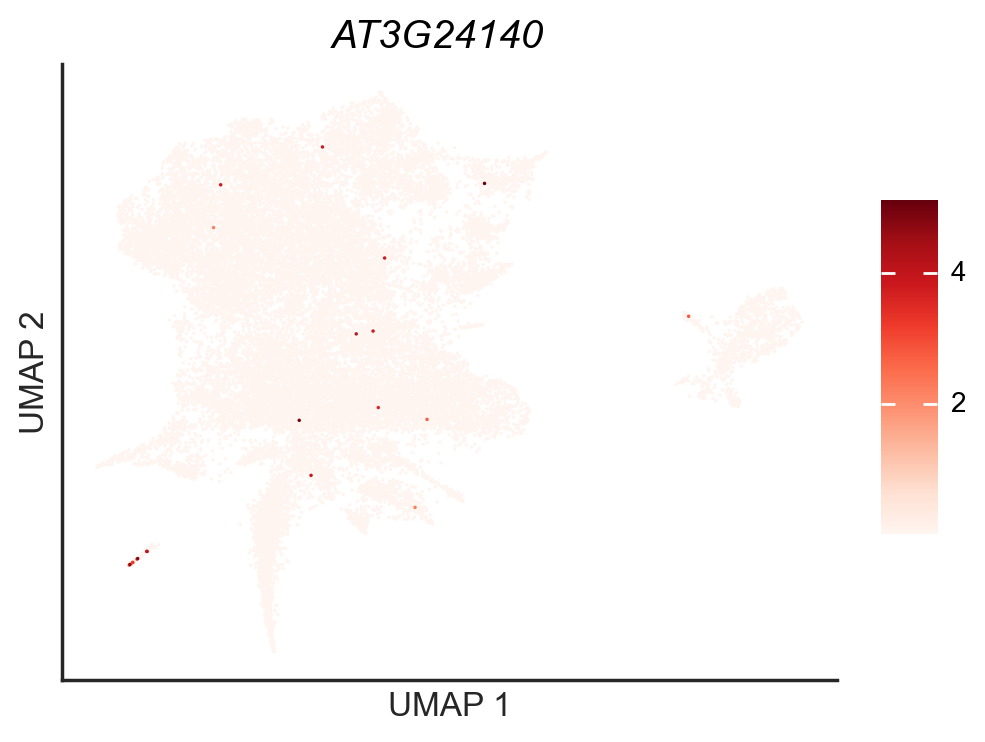

In [ ]:
ead_mut.pl.embedding(color='AT3G24140',figsize=(5,4), size=0.5)

2026-05-15 15:44:34.502 | INFO     | jpy_tools.singleCellTools.plotting:_embedding:1747 - Title location: 0.9008333333333333


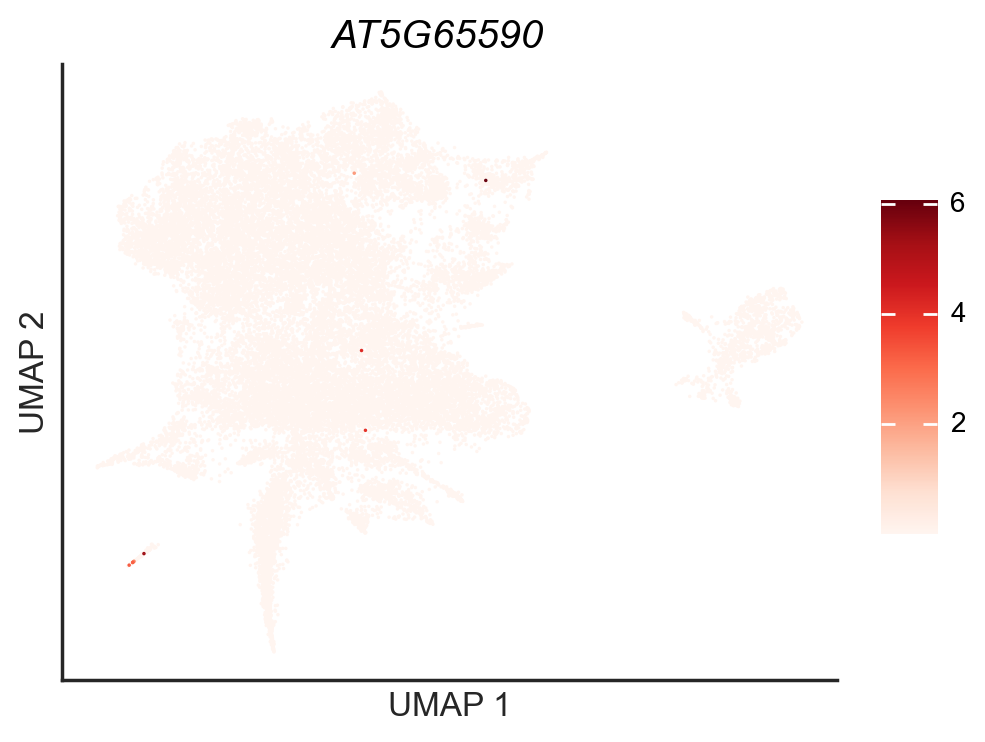

In [ ]:
ead_mut.pl.embedding(color='AT5G65590',figsize=(5,4), size=0.5)

In [ ]:
dt_specGenes = (
    ead.uns["Cluster_ft_cellexES_sketch"]
    .query("enrichScore > 0.95")
    .sort_values(["Cluster_ft", "enrichScore"], ascending=[True, False])
    .groupby("Cluster_ft")["gene"]
    .agg(list)
    .to_dict()
)

In [ ]:
ead_mut.addRef(ead.ad, 'Cluster_ft_anno')

In [ ]:
ead_mut.anno.getAUCellScore(dt_specGenes, aucMaxRank=1000)

Create regulons from a dataframe of enriched features.
Additional columns saved: []


100%|██████████| 3/3 [01:11<00:00, 23.94s/it]


In [ ]:
ead_mut

enhancedAnndata: AnnData object with n_obs × n_vars = 26216 × 37336
    obs: 'sumUmi', 'myb60_group', '__group'
    var: 'highly_variable'
    uns: 'EnhancedAnndata_rawLayer', 'sctModels', 'sct_residual_keys', 'pca', 'neighbors', 'umap', 'myb60_group_colors', 'log1p'
    obsm: 'sct_residual', 'X_pca', 'X_umap', 'X_pca_harmony', 'Cluster_ft_anno_AUC'
    varm: 'highly_variable_rank_sct'
    layers: 'raw', 'normalize_log'
    obsp: 'distances', 'connectivities'
rawLayer: raw
anno: initialized, refLabel: Cluster_ft_anno, refLayer: raw, resultKey: Cluster_ft_anno

2026-05-15 15:46:53.057 | INFO     | jpy_tools.singleCellTools.plotting:_embedding:1747 - Title location: 0.8938888888888888


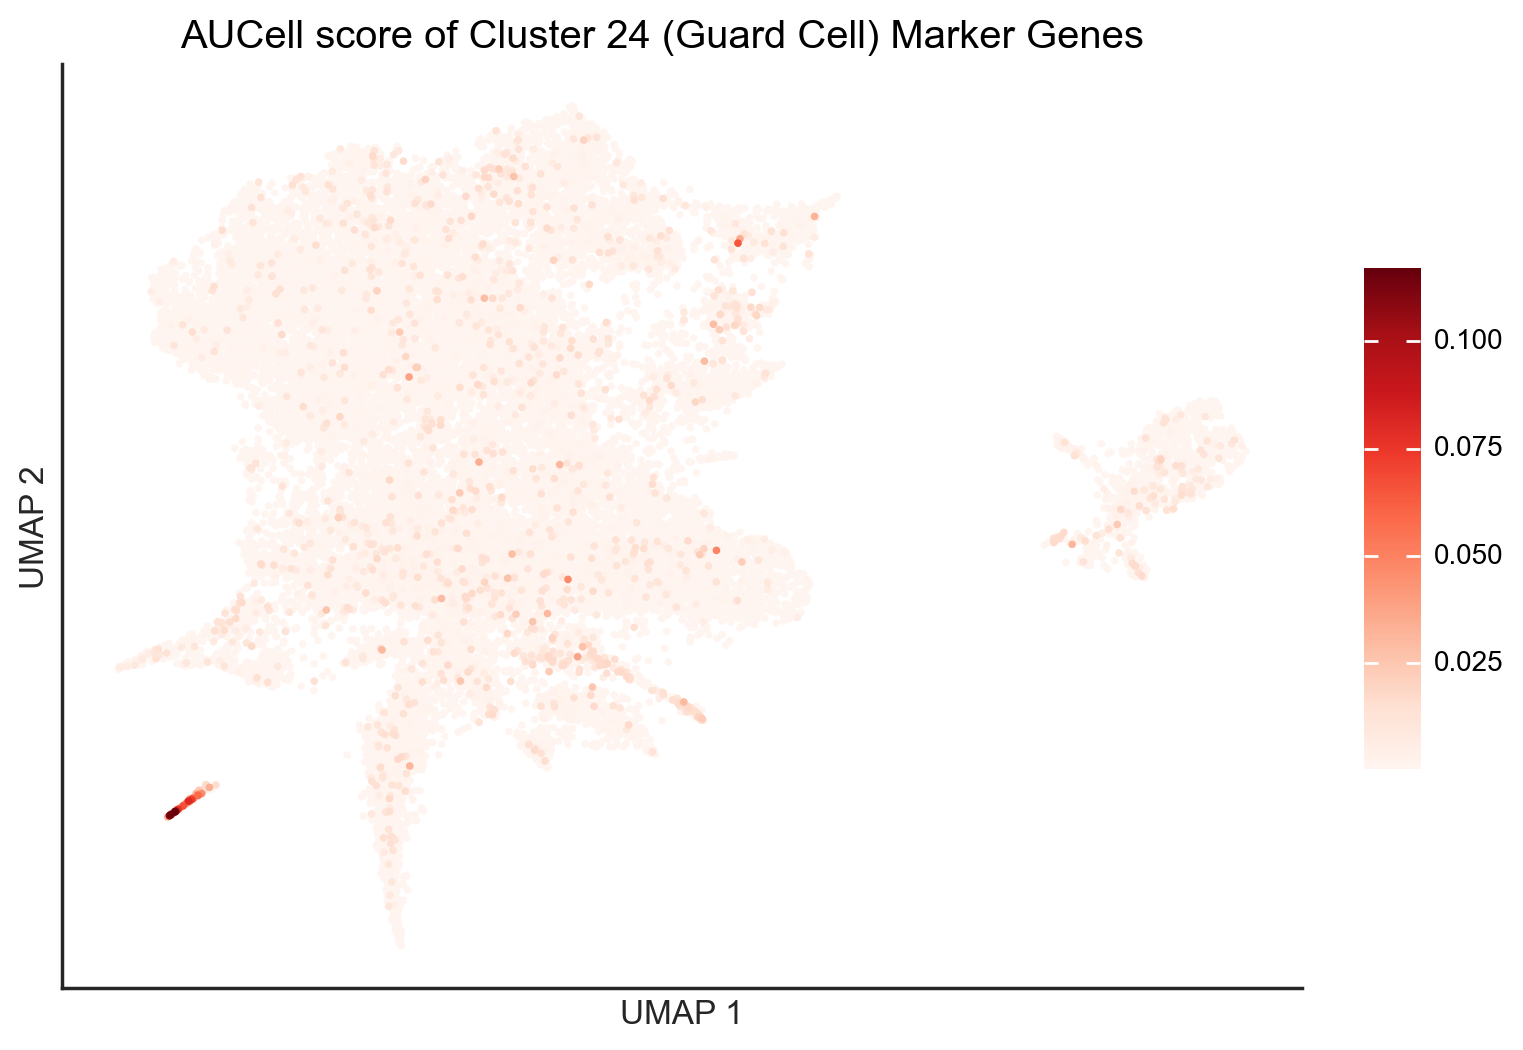

In [ ]:
ead_mut.pl.embedding(color='24', colorUseObsm='Cluster_ft_anno_AUC', title='AUCell score of Cluster 24 (Guard Cell) Marker Genes')

In [ ]:
sc.tl.leiden(ead_mut.ad, resolution=0.2)

2026-05-15 13:22:25.007 | DEBUG    | jpy_tools.singleCellTools.plotting:_embedding:1601 - ls_color: Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype='object')
2026-05-15 13:22:25.954 | INFO     | jpy_tools.singleCellTools.plotting:_embedding:1747 - Title location: 0.8938888888888888


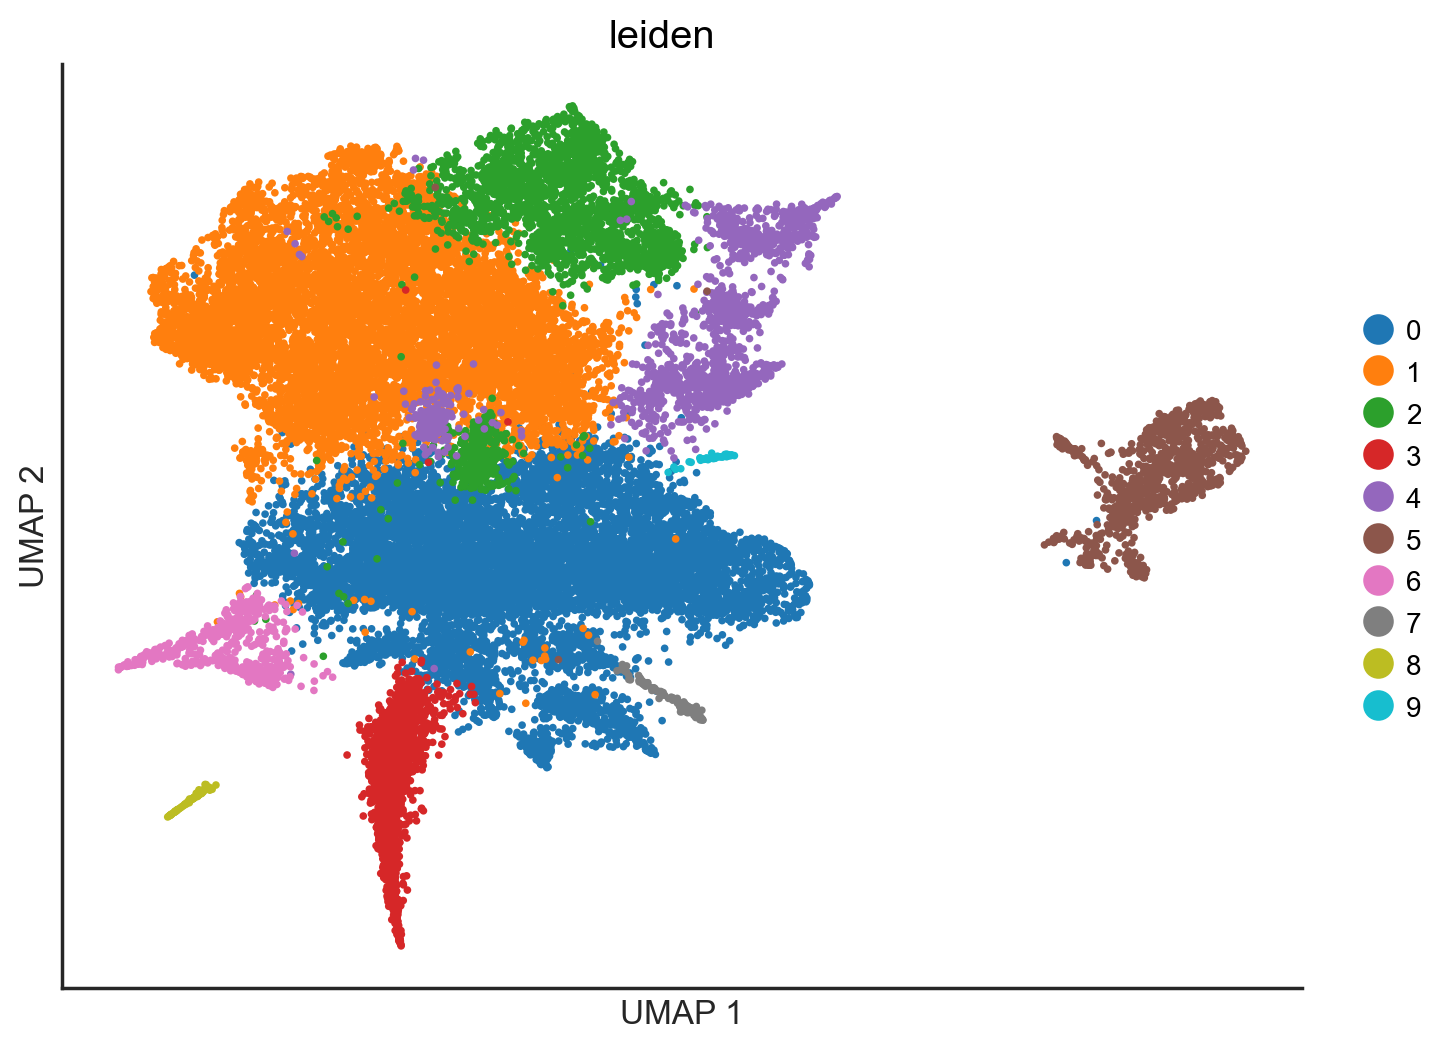

In [ ]:
ead_mut.pl.embedding('umap', color='leiden')

In [ ]:
ead_mut.obs['ct'] = ead_mut.obs['leiden'].map(lambda _: 'Guard Cell' if _ == '8' else 'Others')

# compare with WT

In [ ]:
ead_mut.obs['Treatment'] = ead_mut.obs['myb60_group'].map({'mutDmso':'Mock', 'mutSa':'SA'})

2026-05-15 14:11:07.001 | DEBUG    | jpy_tools.singleCellTools.plotting:_embedding:1601 - ls_color: Index(['Mock', 'SA'], dtype='object')
2026-05-15 14:11:07.679 | INFO     | jpy_tools.singleCellTools.plotting:_embedding:1747 - Title location: 0.8966666666666666


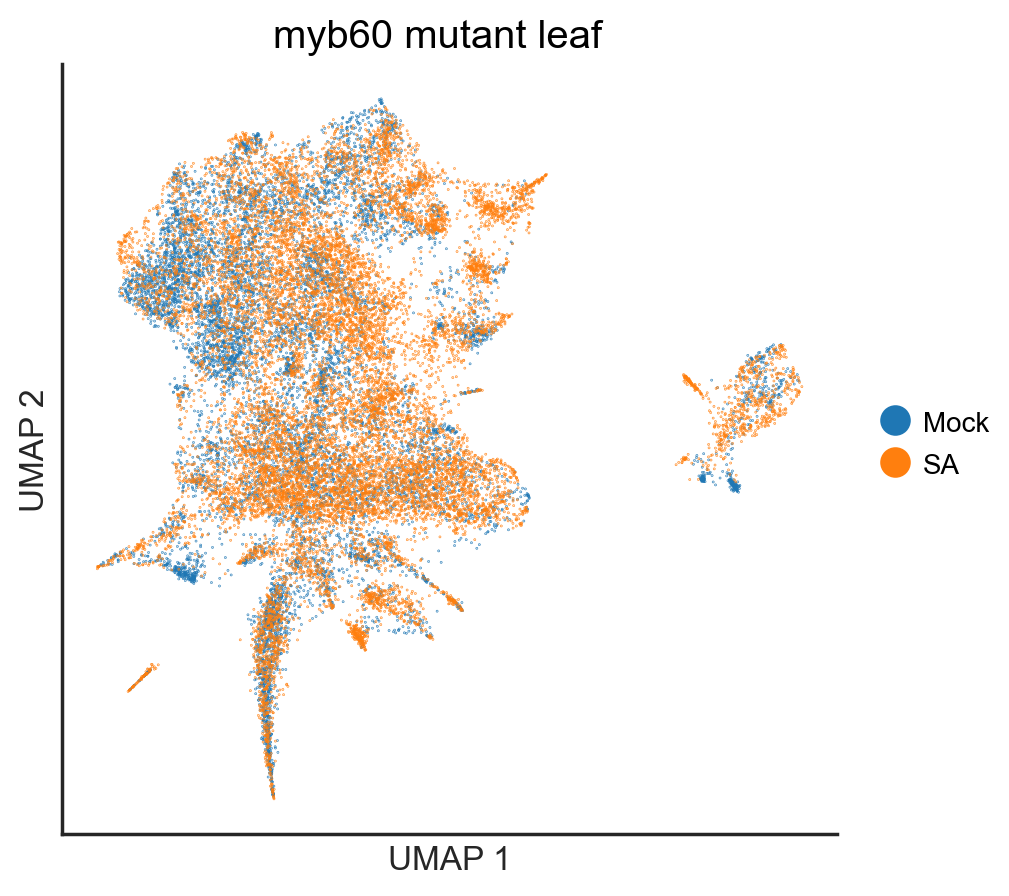

In [ ]:
ead_mut.pl.embedding('umap', color='Treatment', title='myb60 mutant leaf',  figsize=(5,5), size=0.2)

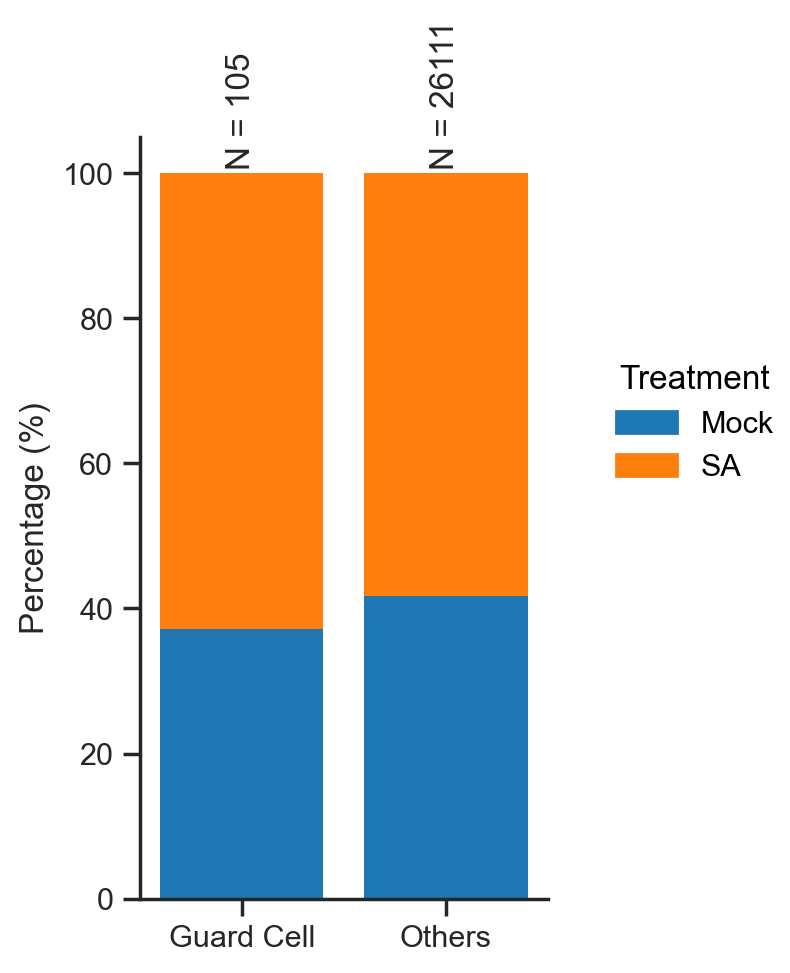

In [ ]:
ead_mut.pl.clusterPercentage(x='ct', y='Treatment', figsize=(3,5), fc_after=lambda _: _.label(x=''))[1]

2026-05-15 15:43:49.626 | INFO     | jpy_tools.singleCellTools.plotting:_embedding:1747 - Title location: 0.9008333333333333


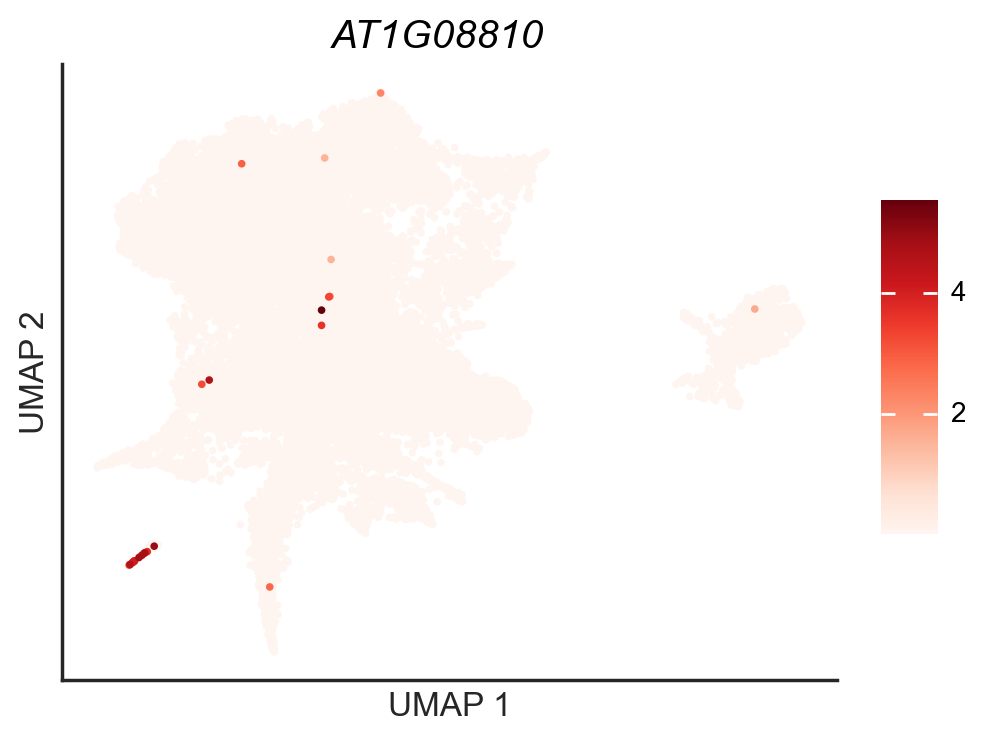

In [ ]:
ead_mutGc = ead_mut[ead_mut.obs.eval("leiden == '8'")].copy()

In [ ]:
ls_myb60TgStoRelated = """AT3G49260
AT4G14480
AT3G56400
AT2G46070
AT5G26000
AT5G54270
AT2G16630
""".split()

In [ ]:
_ls = ['Mock', 'SA']
ead_saDmsoGc = ead[ead.obs.eval("Time == 'Time3h' & Hormone in @_ls & Cluster_ft == '24'")].copy()

In [ ]:
ead_saDmsoGc.X = ead_saDmsoGc.layers['normalize_log'].copy()

In [ ]:
a = np.exp2(ead_mutGc[:, ls_myb60TgStoRelated].to_df('normalize_log')).groupby(ead_mutGc.obs['myb60_group']).mean()
b = np.exp2(ead_saDmsoGc[:, ls_myb60TgStoRelated].to_df('normalize_log')).groupby(ead_saDmsoGc.obs['Hormone']).mean()

In [ ]:
df = pd.concat([a.T.assign(Genotype='myb60 mutant').rename(columns={'mutDmso':'Mock', 'mutSa':'SA'}), b.T.assign(Genotype='Col-0')], axis=0)

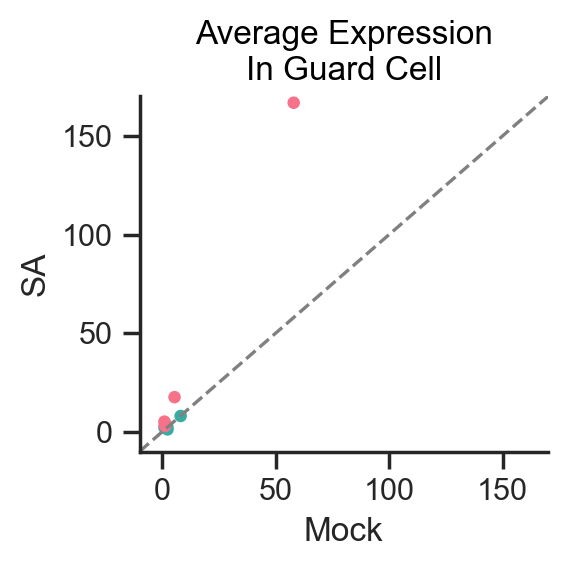

In [ ]:
fig = (
    so.Plot(data=df.reset_index(), x='Mock', y='SA', color='Genotype')
    .add(so.Dot(pointsize=(4)), legend=False)
    .limit(x=(-10,170), y=(-10,170))
    .layout(size=(3,3))
    .scale(x=so.Continuous().tick(every=50), y=so.Continuous().tick(every=50), color=so.Nominal(order=['Col-0', 'myb60 mutant']))
    .label(title='Average Expression\nIn Guard Cell', x='Mock', y='SA')
).plot()._figure
ax = fig.axes[0]
ax.axline((0, 0), (1, 1), transform=ax.transAxes, 
          linestyle='--', color='gray', linewidth=1.2)
fig

In [ ]:
df.assign(sum=lambda _: _.index.map(dt_myb50TgStoRelated))

,Mock,SA,Genotype,sum
AT3G49260,1.938716,2.824644,myb60 mutant,IQD21
AT4G14480,2.345537,1.197143,myb60 mutant,BLUS1
AT3G56400,8.123258,8.012513,myb60 mutant,WRKY70
AT2G46070,2.265544,2.564120,myb60 mutant,MPK12
AT5G26000,1.892545,2.655760,myb60 mutant,TGG1
AT5G54270,1.622355,3.514785,myb60 mutant,LHCB3
AT2G16630,1.000000,2.132797,myb60 mutant,FOCL1
AT3G49260,1.408388,3.901707,Col-0,IQD21
AT4G14480,1.246539,3.559048,Col-0,BLUS1
AT3G56400,1.000000,5.154900,Col-0,WRKY70


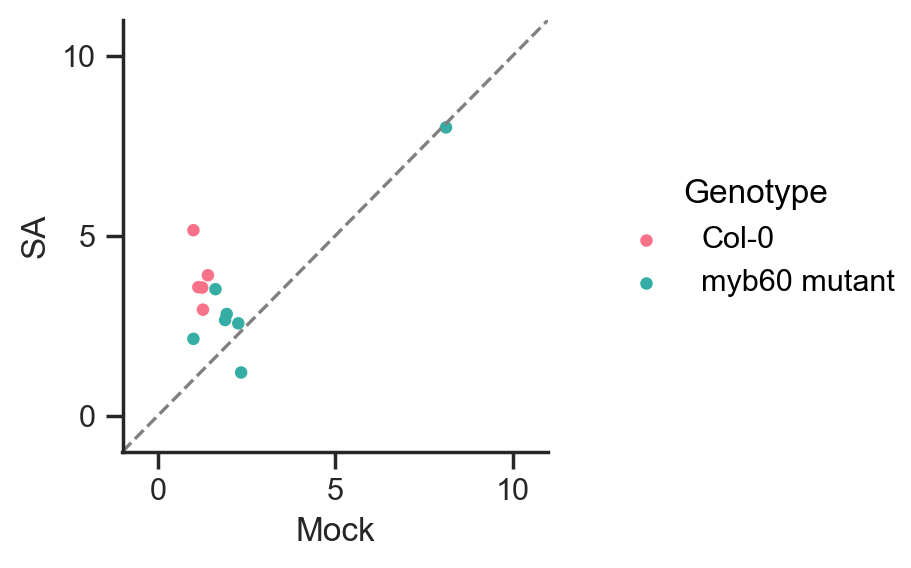

In [ ]:
fig = (
    so.Plot(data=df.reset_index(), x='Mock', y='SA', color='Genotype')
    .add(so.Dot(pointsize=(4)))
    .limit(x=(-1,11), y=(-1,11))
    .layout(size=(3,3))
    .scale(x=so.Continuous().tick(every=5), y=so.Continuous().tick(every=5), color=so.Nominal(order=['Col-0', 'myb60 mutant']))
).plot()._figure
ax = fig.axes[0]
ax.axline((0, 0), (1, 1), transform=ax.transAxes, 
          linestyle='--', color='gray', linewidth=1.2)
fig

In [ ]:
df = pd.concat([a.T.assign(Genotype='myb60 mutant').rename(columns={'mutDmso':'Mock', 'mutSa':'SA'}), b.T.assign(Genotype='Col-0')], axis=1)

In [ ]:
df = pd.concat([(a.T['mutSa'] / a.T['mutDmso']).rename('myb60 mutant'), (b.T['SA'] / b.T['Mock']).rename('Col-0')], axis=1)

In [ ]:
df = df.melt(ignore_index=False).rename_axis('Gene').reset_index()

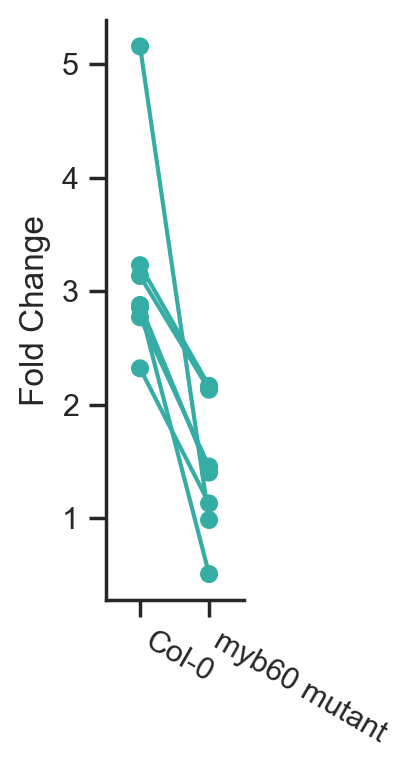

In [ ]:
fig = (
    so.Plot(data=df, x='variable', y='value', group='Gene')
    .add(so.Line(color='#36ada4'))
    .add(so.Dot(color='#36ada4'))
    .scale(x=so.Nominal(order=['Col-0', 'myb60 mutant']))
    .label(x='', y='Fold Change')
    .layout(size=(2,4))
).plot()._figure
ax = fig.axes[0]
ax.set_xticklabels(ax.get_xticklabels(), rotation=-30, ha='left')
fig

In [ ]:
df.assign(sum=lambda _: _.Gene.map(dt_myb50TgStoRelated)).sort_values(['variable', 'value'])

,Gene,variable,value,sum
10,AT2G46070,Col-0,2.320963,MPK12
7,AT3G49260,Col-0,2.770336,IQD21
8,AT4G14480,Col-0,2.855145,BLUS1
11,AT5G26000,Col-0,2.878984,TGG1
13,AT2G16630,Col-0,3.134038,FOCL1
12,AT5G54270,Col-0,3.229046,LHCB3
9,AT3G56400,Col-0,5.154900,WRKY70
1,AT4G14480,myb60 mutant,0.510392,BLUS1
2,AT3G56400,myb60 mutant,0.986367,WRKY70
3,AT2G46070,myb60 mutant,1.131790,MPK12


# phenotype

In [ ]:
str_ = """genotype	treatment	phase	time_point	time_hours	biological_replicate	measurement_id	stomatal_state	stomatal_length	stomatal_width	aperture_ratio	measurement_note	source_sheet	source_row
Col-0	DMSO	Before treatment	Treatment 0 h	0	1	1	measured	3.367	1.046	0.310662311		Sheet1	3
Col-0	DMSO	Before treatment	Treatment 0 h	0	1	2	measured	2.437	1.39	0.57037341		Sheet1	4
Col-0	DMSO	Before treatment	Treatment 0 h	0	1	3	measured	2.704	1.534	0.567307692		Sheet1	5
Col-0	DMSO	Before treatment	Treatment 0 h	0	1	4	measured	2.545	1.212	0.476227898		Sheet1	6
Col-0	DMSO	Before treatment	Treatment 0 h	0	1	5	measured	3.843	1.26	0.327868852		Sheet1	7
Col-0	DMSO	Before treatment	Treatment 0 h	0	1	6	measured	2.566	1.139	0.443881528		Sheet1	8
Col-0	DMSO	Before treatment	Treatment 0 h	0	1	7	measured	4.144	1.246	0.300675676		Sheet1	9
Col-0	DMSO	Before treatment	Treatment 0 h	0	1	8	measured	2.052	1.17	0.570175439		Sheet1	10
Col-0	DMSO	Before treatment	Treatment 0 h	0	1	9	measured	3.566	1.073	0.300897364		Sheet1	11
Col-0	DMSO	Before treatment	Treatment 0 h	0	1	10	measured	3.127	1.128	0.360729133		Sheet1	12
Col-0	DMSO	Before treatment	Treatment 0 h	0	1	11	measured	3.54	1.446	0.408474576		Sheet1	13
Col-0	DMSO	Before treatment	Treatment 0 h	0	1	12	measured	3.555	1.58	0.444444444		Sheet1	14
Col-0	DMSO	Before treatment	Treatment 0 h	0	1	13	measured	2.954	1.62	0.548408937		Sheet1	15
Col-0	DMSO	Before treatment	Treatment 0 h	0	1	14	measured	2.694	1.29	0.478841871		Sheet1	16
Col-0	DMSO	Before treatment	Treatment 0 h	0	1	15	measured	3.833	1.643	0.428645969		Sheet1	17
Col-0	DMSO	Before treatment	Treatment 0 h	0	1	16	measured	2.688	1.291	0.480282738		Sheet1	18
Col-0	DMSO	Before treatment	Treatment 0 h	0	1	17	measured	3.003	1.316	0.438228438		Sheet1	19
Col-0	DMSO	Before treatment	Treatment 0 h	0	1	18	measured	1.704	1.507	0.884389671		Sheet1	20
Col-0	DMSO	Before treatment	Treatment 0 h	0	1	19	measured	3.024	1.454	0.480820106		Sheet1	21
Col-0	DMSO	Before treatment	Treatment 0 h	0	1	20	measured	1.774	0.93	0.524239008		Sheet1	22
Col-0	DMSO	Before treatment	Treatment 0 h	0	1	21	measured	2.134	1.116	0.522961575		Sheet1	23
Col-0	DMSO	Before treatment	Treatment 0 h	0	2	1	measured	3.015	1.378	0.457048093		Sheet1	3
Col-0	DMSO	Before treatment	Treatment 0 h	0	2	2	measured	1.718	1.042	0.606519208		Sheet1	4
Col-0	DMSO	Before treatment	Treatment 0 h	0	2	3	measured	2.302	1.237	0.537358818		Sheet1	5
Col-0	DMSO	Before treatment	Treatment 0 h	0	2	4	measured	1.839	1.192	0.648178358		Sheet1	6
Col-0	DMSO	Before treatment	Treatment 0 h	0	2	5	measured	3.737	1.765	0.472303987		Sheet1	7
Col-0	DMSO	Before treatment	Treatment 0 h	0	2	6	measured	3.591	1.514	0.42160958		Sheet1	8
Col-0	DMSO	Before treatment	Treatment 0 h	0	2	7	measured	2.48	1.237	0.498790323		Sheet1	9
Col-0	DMSO	Before treatment	Treatment 0 h	0	2	8	measured	2.083	1.294	0.621219395		Sheet1	10
Col-0	DMSO	Before treatment	Treatment 0 h	0	2	9	measured	2.04	1.294	0.634313725		Sheet1	11
Col-0	DMSO	Before treatment	Treatment 0 h	0	2	10	measured	3.128	1.254	0.400895141		Sheet1	12
Col-0	DMSO	Before treatment	Treatment 0 h	0	2	11	measured	2.444	1.138	0.465630115		Sheet1	13
Col-0	DMSO	Before treatment	Treatment 0 h	0	2	12	measured	4.638	1.471	0.31716257		Sheet1	14
Col-0	DMSO	Before treatment	Treatment 0 h	0	2	13	measured	2.405	1.278	0.531392931		Sheet1	15
Col-0	DMSO	Before treatment	Treatment 0 h	0	2	14	measured	3.658	1.386	0.378895571		Sheet1	16
Col-0	DMSO	Before treatment	Treatment 0 h	0	2	15	measured	2.503	1.321	0.52776668		Sheet1	17
Col-0	DMSO	Before treatment	Treatment 0 h	0	2	16	measured	0.8	0.498	0.6225		Sheet1	18
Col-0	DMSO	Before treatment	Treatment 0 h	0	2	17	measured	2.458	1.089	0.443043124		Sheet1	19
Col-0	DMSO	Before treatment	Treatment 0 h	0	2	18	measured	2.291	1.363	0.594936709		Sheet1	20
Col-0	DMSO	Before treatment	Treatment 0 h	0	2	19	measured	1.68	1.316	0.783333333		Sheet1	21
Col-0	DMSO	Treatment	Treatment 3 h	3	1	1	measured	1.314	0.532	0.404870624		Sheet1	55
Col-0	DMSO	Treatment	Treatment 3 h	3	1	2	measured	3.552	0.601	0.16920045		Sheet1	56
Col-0	DMSO	Treatment	Treatment 3 h	3	1	3	measured	2.364	0.93	0.393401015		Sheet1	57
Col-0	DMSO	Treatment	Treatment 3 h	3	1	4	measured	2.944	0.971	0.32982337		Sheet1	58
Col-0	DMSO	Treatment	Treatment 3 h	3	1	5	measured	3.294	1.109	0.336672738		Sheet1	59
Col-0	DMSO	Treatment	Treatment 3 h	3	1	6	measured	2.607	1.192	0.457230533		Sheet1	60
Col-0	DMSO	Treatment	Treatment 3 h	3	1	7	measured	1.716	1.282	0.747086247		Sheet1	61
Col-0	DMSO	Treatment	Treatment 3 h	3	1	8	measured	3.163	1.434	0.453367057		Sheet1	62
Col-0	DMSO	Treatment	Treatment 3 h	3	1	9	measured	2.292	1.085	0.473385689		Sheet1	63
Col-0	DMSO	Treatment	Treatment 3 h	3	1	10	measured	2.41	0.991	0.41120332		Sheet1	64
Col-0	DMSO	Treatment	Treatment 3 h	3	1	11	measured	2.379	1.162	0.488440521		Sheet1	65
Col-0	DMSO	Treatment	Treatment 3 h	3	1	12	measured	3.098	1.336	0.431245965		Sheet1	66
Col-0	DMSO	Treatment	Treatment 3 h	3	1	13	measured	2.83	1.023	0.361484099		Sheet1	67
Col-0	DMSO	Treatment	Treatment 3 h	3	1	14	measured	3.85	1.239	0.321818182		Sheet1	68
Col-0	DMSO	Treatment	Treatment 3 h	3	1	15	measured	3.19	0.832	0.260815047		Sheet1	69
Col-0	DMSO	Treatment	Treatment 3 h	3	1	16	measured	1.976	0.621	0.314271255		Sheet1	70
Col-0	DMSO	Treatment	Treatment 3 h	3	1	17	measured	1.417	0.485	0.342272406		Sheet1	71
Col-0	DMSO	Treatment	Treatment 3 h	3	1	18	measured	3.068	1.282	0.417861799		Sheet1	72
Col-0	DMSO	Treatment	Treatment 3 h	3	1	19	measured	2.83	1.124	0.397173145		Sheet1	73
Col-0	DMSO	Treatment	Treatment 3 h	3	2	1	measured	1.572	0.659	0.419211196		Sheet1	55
Col-0	DMSO	Treatment	Treatment 3 h	3	2	2	measured	2.876	0.762	0.264951321		Sheet1	56
Col-0	DMSO	Treatment	Treatment 3 h	3	2	3	measured	4.856	0.988	0.203459638		Sheet1	57
Col-0	DMSO	Treatment	Treatment 3 h	3	2	4	measured	2.378	0.929	0.390664424		Sheet1	58
Col-0	DMSO	Treatment	Treatment 3 h	3	2	5	measured	2.246	0.843	0.375333927		Sheet1	59
Col-0	DMSO	Treatment	Treatment 3 h	3	2	6	measured	2.648	0.666	0.251510574		Sheet1	60
Col-0	DMSO	Treatment	Treatment 3 h	3	2	7	measured	1.962	0.711	0.362385321		Sheet1	61
Col-0	DMSO	Treatment	Treatment 3 h	3	2	8	measured	1.898	0.968	0.510010537		Sheet1	62
Col-0	DMSO	Treatment	Treatment 3 h	3	2	9	measured	2.222	0.952	0.428442844		Sheet1	63
Col-0	DMSO	Treatment	Treatment 3 h	3	2	10	measured	1.237	0.771	0.623282134		Sheet1	64
Col-0	DMSO	Treatment	Treatment 3 h	3	2	11	measured	3.347	1.12	0.334628025		Sheet1	65
Col-0	DMSO	Treatment	Treatment 3 h	3	2	12	measured	1.12	0.602	0.5375		Sheet1	66
Col-0	DMSO	Treatment	Treatment 3 h	3	2	13	measured	1.458	0.645	0.442386831		Sheet1	67
Col-0	DMSO	Treatment	Treatment 3 h	3	2	14	measured	2.637	1.424	0.540007584		Sheet1	68
Col-0	DMSO	Treatment	Treatment 3 h	3	2	15	measured	3.558	0.859	0.241427768		Sheet1	69
Col-0	DMSO	Recovery	Recovery 24 h	24	1	1	measured	1.432	0.619	0.43226257		Sheet1	78
Col-0	DMSO	Recovery	Recovery 24 h	24	1	2	measured	2.408	0.852	0.353820598		Sheet1	79
Col-0	DMSO	Recovery	Recovery 24 h	24	1	3	measured	2.629	1.314	0.499809814		Sheet1	80
Col-0	DMSO	Recovery	Recovery 24 h	24	1	4	measured	1.446	0.649	0.448824343		Sheet1	81
Col-0	DMSO	Recovery	Recovery 24 h	24	1	5	measured	2.093	0.987	0.471571906		Sheet1	82
Col-0	DMSO	Recovery	Recovery 24 h	24	1	6	measured	2.791	1.288	0.461483339		Sheet1	83
Col-0	DMSO	Recovery	Recovery 24 h	24	1	7	measured	2.425	1.095	0.451546392		Sheet1	84
Col-0	DMSO	Recovery	Recovery 24 h	24	1	8	measured	2.179	0.989	0.453877926		Sheet1	85
Col-0	DMSO	Recovery	Recovery 24 h	24	1	9	measured	1.217	0.573	0.47082991		Sheet1	86
Col-0	DMSO	Recovery	Recovery 24 h	24	1	10	measured	1.346	0.619	0.459881129		Sheet1	87
Col-0	DMSO	Recovery	Recovery 24 h	24	1	11	measured	1.57	0.795	0.506369427		Sheet1	88
Col-0	DMSO	Recovery	Recovery 24 h	24	1	12	measured	1.889	0.932	0.493382742		Sheet1	89
Col-0	DMSO	Recovery	Recovery 24 h	24	2	1	measured	1.762	0.853	0.484108967		Sheet1	78
Col-0	DMSO	Recovery	Recovery 24 h	24	2	2	measured	4.162	1.56	0.374819798		Sheet1	79
Col-0	DMSO	Recovery	Recovery 24 h	24	2	3	measured	4.01	1.417	0.353366584		Sheet1	80
Col-0	DMSO	Recovery	Recovery 24 h	24	2	4	measured	2.275	1.064	0.467692308		Sheet1	81
Col-0	DMSO	Recovery	Recovery 24 h	24	2	5	measured	2.771	1.592	0.574521833		Sheet1	82
Col-0	DMSO	Recovery	Recovery 24 h	24	2	6	measured	2.448	1.469	0.600081699		Sheet1	83
Col-0	DMSO	Recovery	Recovery 24 h	24	2	7	measured	2.306	1.042	0.451864701		Sheet1	84
Col-0	DMSO	Recovery	Recovery 24 h	24	2	8	measured	2.485	1.243	0.500201207		Sheet1	85
Col-0	DMSO	Recovery	Recovery 24 h	24	2	9	measured	3.034	0.904	0.297956493		Sheet1	86
Col-0	DMSO	Recovery	Recovery 24 h	24	2	10	measured	1.965	0.844	0.429516539		Sheet1	87
Col-0	DMSO	Recovery	Recovery 24 h	24	2	11	measured	3.133	1.358	0.433450367		Sheet1	88
Col-0	DMSO	Recovery	Recovery 24 h	24	2	12	measured	2.688	1.156	0.430059524		Sheet1	89
Col-0	DMSO	Recovery	Recovery 48 h	48	1	1	measured	2.459	1.396	0.567710451	measurement_id_generated	Sheet1	94
Col-0	DMSO	Recovery	Recovery 48 h	48	1	2	measured	2.671	1.2	0.449269936	measurement_id_generated	Sheet1	95
Col-0	DMSO	Recovery	Recovery 48 h	48	1	3	measured	3.726	1.201	0.322329576	measurement_id_generated	Sheet1	96
Col-0	DMSO	Recovery	Recovery 48 h	48	1	4	measured	2.356	0.877	0.372241087	measurement_id_generated	Sheet1	97
Col-0	DMSO	Recovery	Recovery 48 h	48	1	5	measured	3.1	1.122	0.361935484	measurement_id_generated	Sheet1	98
Col-0	DMSO	Recovery	Recovery 48 h	48	1	6	measured	4.523	1.506	0.332964846	measurement_id_generated	Sheet1	99
Col-0	DMSO	Recovery	Recovery 48 h	48	1	7	measured	3.438	1.215	0.353403141	measurement_id_generated	Sheet1	100
Col-0	DMSO	Recovery	Recovery 48 h	48	1	8	measured	3.2	1.107	0.3459375	measurement_id_generated	Sheet1	101
Col-0	DMSO	Recovery	Recovery 48 h	48	1	9	measured	3.793	1.09	0.287371474	measurement_id_generated	Sheet1	102
Col-0	DMSO	Recovery	Recovery 48 h	48	1	10	measured	3.458	1.652	0.477732794	measurement_id_generated	Sheet1	103
Col-0	DMSO	Recovery	Recovery 48 h	48	1	11	measured	3.417	1.681	0.491952005	measurement_id_generated	Sheet1	104
Col-0	DMSO	Recovery	Recovery 48 h	48	1	12	measured	3.43	1.203	0.350728863	measurement_id_generated	Sheet1	105
Col-0	DMSO	Recovery	Recovery 48 h	48	2	1	measured	2.349	1.047	0.445721584		Sheet1	94
Col-0	DMSO	Recovery	Recovery 48 h	48	2	2	measured	3.077	0.767	0.249268768		Sheet1	95
Col-0	DMSO	Recovery	Recovery 48 h	48	2	3	measured	1.409	0.431	0.305890703		Sheet1	96
Col-0	DMSO	Recovery	Recovery 48 h	48	2	4	measured	1.465	0.606	0.413651877		Sheet1	97
Col-0	DMSO	Recovery	Recovery 48 h	48	2	5	measured	3.424	1.526	0.44567757		Sheet1	98
Col-0	DMSO	Recovery	Recovery 48 h	48	2	6	measured	2.679	1.152	0.430011198		Sheet1	99
Col-0	DMSO	Recovery	Recovery 48 h	48	2	7	measured	1.699	0.779	0.458505003		Sheet1	100
Col-0	DMSO	Recovery	Recovery 48 h	48	2	8	measured	1.612	0.608	0.377171216		Sheet1	101
Col-0	DMSO	Recovery	Recovery 48 h	48	2	9	measured	2.836	0.979	0.345204513		Sheet1	102
Col-0	DMSO	Recovery	Recovery 48 h	48	2	10	measured	1.819	0.806	0.443100605		Sheet1	103
Col-0	DMSO	Recovery	Recovery 48 h	48	2	11	measured	3.391	1.306	0.385137128		Sheet1	104
Col-0	DMSO	Recovery	Recovery 48 h	48	2	12	measured	3.362	1.091	0.324509221		Sheet1	105
Col-0	DMSO	Recovery	Recovery 48 h	48	2	13	measured	2.931	1.294	0.441487547		Sheet1	106
Col-0	DMSO	Recovery	Recovery 48 h	48	2	14	measured	2.03	1.231	0.606403941		Sheet1	107
Col-0	DMSO	Recovery	Recovery 48 h	48	2	15	measured	2.462	0.871	0.353777417		Sheet1	108
Col-0	DMSO	Recovery	Recovery 48 h	48	2	16	measured	2.997	1.038	0.346346346		Sheet1	109
Col-0	DMSO	Recovery	Recovery 48 h	48	2	17	measured	1.478	0.562	0.380243572		Sheet1	110
Col-0	DMSO	Recovery	Recovery 48 h	48	2	18	measured	2.659	1.116	0.419706657		Sheet1	111
Col-0	SA	Before treatment	Treatment 0 h	0	1	1	measured	3.367	1.046	0.310662311		Sheet1	3
Col-0	SA	Before treatment	Treatment 0 h	0	1	2	measured	2.437	1.39	0.57037341		Sheet1	4
Col-0	SA	Before treatment	Treatment 0 h	0	1	3	measured	2.704	1.534	0.567307692		Sheet1	5
Col-0	SA	Before treatment	Treatment 0 h	0	1	4	measured	2.545	1.212	0.476227898		Sheet1	6
Col-0	SA	Before treatment	Treatment 0 h	0	1	5	measured	3.843	1.26	0.327868852		Sheet1	7
Col-0	SA	Before treatment	Treatment 0 h	0	1	6	measured	2.566	1.139	0.443881528		Sheet1	8
Col-0	SA	Before treatment	Treatment 0 h	0	1	7	measured	4.144	1.246	0.300675676		Sheet1	9
Col-0	SA	Before treatment	Treatment 0 h	0	1	8	measured	2.052	1.17	0.570175439		Sheet1	10
Col-0	SA	Before treatment	Treatment 0 h	0	1	9	measured	3.566	1.073	0.300897364		Sheet1	11
Col-0	SA	Before treatment	Treatment 0 h	0	1	10	measured	3.127	1.128	0.360729133		Sheet1	12
Col-0	SA	Before treatment	Treatment 0 h	0	1	11	measured	3.54	1.446	0.408474576		Sheet1	13
Col-0	SA	Before treatment	Treatment 0 h	0	1	12	measured	3.555	1.58	0.444444444		Sheet1	14
Col-0	SA	Before treatment	Treatment 0 h	0	1	13	measured	2.954	1.62	0.548408937		Sheet1	15
Col-0	SA	Before treatment	Treatment 0 h	0	1	14	measured	2.694	1.29	0.478841871		Sheet1	16
Col-0	SA	Before treatment	Treatment 0 h	0	1	15	measured	3.833	1.643	0.428645969		Sheet1	17
Col-0	SA	Before treatment	Treatment 0 h	0	1	16	measured	2.688	1.291	0.480282738		Sheet1	18
Col-0	SA	Before treatment	Treatment 0 h	0	1	17	measured	3.003	1.316	0.438228438		Sheet1	19
Col-0	SA	Before treatment	Treatment 0 h	0	1	18	measured	1.704	1.507	0.884389671		Sheet1	20
Col-0	SA	Before treatment	Treatment 0 h	0	1	19	measured	3.024	1.454	0.480820106		Sheet1	21
Col-0	SA	Before treatment	Treatment 0 h	0	1	20	measured	1.774	0.93	0.524239008		Sheet1	22
Col-0	SA	Before treatment	Treatment 0 h	0	1	21	measured	2.134	1.116	0.522961575		Sheet1	23
Col-0	SA	Before treatment	Treatment 0 h	0	2	1	measured	3.015	1.378	0.457048093		Sheet1	3
Col-0	SA	Before treatment	Treatment 0 h	0	2	2	measured	1.718	1.042	0.606519208		Sheet1	4
Col-0	SA	Before treatment	Treatment 0 h	0	2	3	measured	2.302	1.237	0.537358818		Sheet1	5
Col-0	SA	Before treatment	Treatment 0 h	0	2	4	measured	1.839	1.192	0.648178358		Sheet1	6
Col-0	SA	Before treatment	Treatment 0 h	0	2	5	measured	3.737	1.765	0.472303987		Sheet1	7
Col-0	SA	Before treatment	Treatment 0 h	0	2	6	measured	3.591	1.514	0.42160958		Sheet1	8
Col-0	SA	Before treatment	Treatment 0 h	0	2	7	measured	2.48	1.237	0.498790323		Sheet1	9
Col-0	SA	Before treatment	Treatment 0 h	0	2	8	measured	2.083	1.294	0.621219395		Sheet1	10
Col-0	SA	Before treatment	Treatment 0 h	0	2	9	measured	2.04	1.294	0.634313725		Sheet1	11
Col-0	SA	Before treatment	Treatment 0 h	0	2	10	measured	3.128	1.254	0.400895141		Sheet1	12
Col-0	SA	Before treatment	Treatment 0 h	0	2	11	measured	2.444	1.138	0.465630115		Sheet1	13
Col-0	SA	Before treatment	Treatment 0 h	0	2	12	measured	4.638	1.471	0.31716257		Sheet1	14
Col-0	SA	Before treatment	Treatment 0 h	0	2	13	measured	2.405	1.278	0.531392931		Sheet1	15
Col-0	SA	Before treatment	Treatment 0 h	0	2	14	measured	3.658	1.386	0.378895571		Sheet1	16
Col-0	SA	Before treatment	Treatment 0 h	0	2	15	measured	2.503	1.321	0.52776668		Sheet1	17
Col-0	SA	Before treatment	Treatment 0 h	0	2	16	measured	0.8	0.498	0.6225		Sheet1	18
Col-0	SA	Before treatment	Treatment 0 h	0	2	17	measured	2.458	1.089	0.443043124		Sheet1	19
Col-0	SA	Before treatment	Treatment 0 h	0	2	18	measured	2.291	1.363	0.594936709		Sheet1	20
Col-0	SA	Before treatment	Treatment 0 h	0	2	19	measured	1.68	1.316	0.783333333		Sheet1	21
Col-0	SA	Treatment	Treatment 3 h	3	1	1	measured	2.957	0.716	0.242137301		Sheet1	116
Col-0	SA	Treatment	Treatment 3 h	3	1	2	measured	2.601	0.565	0.217224145		Sheet1	117
Col-0	SA	Treatment	Treatment 3 h	3	1	3	measured	2.029	0.592	0.291769345		Sheet1	118
Col-0	SA	Treatment	Treatment 3 h	3	1	4	measured	2.813	0.995	0.353714895		Sheet1	119
Col-0	SA	Treatment	Treatment 3 h	3	1	5	measured	3.562	0.856	0.24031443		Sheet1	120
Col-0	SA	Treatment	Treatment 3 h	3	1	6	measured	2.75	0.791	0.287636364		Sheet1	121
Col-0	SA	Treatment	Treatment 3 h	3	1	7	measured	2.871	0.822	0.28631139		Sheet1	122
Col-0	SA	Treatment	Treatment 3 h	3	1	8	measured	1.336	0.513	0.383982036		Sheet1	123
Col-0	SA	Treatment	Treatment 3 h	3	1	9	measured	3.159	0.636	0.201329535		Sheet1	124
Col-0	SA	Treatment	Treatment 3 h	3	1	10	measured	2.959	0.727	0.245691112		Sheet1	125
Col-0	SA	Treatment	Treatment 3 h	3	1	11	measured	3.121	0.624	0.199935918		Sheet1	126
Col-0	SA	Treatment	Treatment 3 h	3	1	12	measured	2.449	0.809	0.330338914		Sheet1	127
Col-0	SA	Treatment	Treatment 3 h	3	1	13	measured	2.072	0.453	0.218629344	measurement_id_generated	Sheet1	128
Col-0	SA	Treatment	Treatment 3 h	3	2	1	measured	1.794	0.828	0.461538462		Sheet1	116
Col-0	SA	Treatment	Treatment 3 h	3	2	2	measured	2.76	0.439	0.159057971		Sheet1	117
Col-0	SA	Treatment	Treatment 3 h	3	2	3	measured	2.441	0.64	0.262187628		Sheet1	118
Col-0	SA	Treatment	Treatment 3 h	3	2	4	measured	2.982	0.747	0.250503018		Sheet1	119
Col-0	SA	Treatment	Treatment 3 h	3	2	5	measured	2.727	0.716	0.262559589		Sheet1	120
Col-0	SA	Treatment	Treatment 3 h	3	2	6	measured	2.32	0.551	0.2375		Sheet1	121
Col-0	SA	Treatment	Treatment 3 h	3	2	7	measured	2.481	0.79	0.318419992		Sheet1	122
Col-0	SA	Treatment	Treatment 3 h	3	2	8	measured	2.582	0.878	0.340046476		Sheet1	123
Col-0	SA	Treatment	Treatment 3 h	3	2	9	measured	2.539	0.687	0.270578968		Sheet1	124
Col-0	SA	Treatment	Treatment 3 h	3	2	10	measured	3.085	0.953	0.3089141		Sheet1	125
Col-0	SA	Treatment	Treatment 3 h	3	2	11	measured	2.898	0.872	0.30089717		Sheet1	126
Col-0	SA	Treatment	Treatment 3 h	3	2	12	measured	3.054	0.411	0.134577603		Sheet1	127
Col-0	SA	Recovery	Recovery 24 h	24	1	1	measured	5.095	1.899	0.372718351		Sheet1	133
Col-0	SA	Recovery	Recovery 24 h	24	1	2	measured	5.441	1.814	0.333394597		Sheet1	134
Col-0	SA	Recovery	Recovery 24 h	24	1	3	measured	4.074	1.831	0.449435444		Sheet1	135
Col-0	SA	Recovery	Recovery 24 h	24	1	4	measured	2.444	1.473	0.602700491		Sheet1	136
Col-0	SA	Recovery	Recovery 24 h	24	1	5	measured	5.451	1.095	0.200880572		Sheet1	137
Col-0	SA	Recovery	Recovery 24 h	24	1	6	measured	3.321	2.193	0.66034327		Sheet1	138
Col-0	SA	Recovery	Recovery 24 h	24	1	7	measured	3.428	1.5	0.437572929		Sheet1	139
Col-0	SA	Recovery	Recovery 24 h	24	1	8	measured	4.526	1.579	0.348873177		Sheet1	140
Col-0	SA	Recovery	Recovery 24 h	24	1	9	measured	3.877	1.716	0.442610266		Sheet1	141
Col-0	SA	Recovery	Recovery 24 h	24	1	10	measured	4.53	1.954	0.431346578		Sheet1	142
Col-0	SA	Recovery	Recovery 24 h	24	1	11	measured	1.6	0.787	0.491875		Sheet1	143
Col-0	SA	Recovery	Recovery 24 h	24	1	12	measured	4.617	1.603	0.347195148		Sheet1	144
Col-0	SA	Recovery	Recovery 24 h	24	1	13	measured	5.505	1.858	0.337511353		Sheet1	145
Col-0	SA	Recovery	Recovery 24 h	24	1	14	measured	4.401	2.313	0.525562372		Sheet1	146
Col-0	SA	Recovery	Recovery 24 h	24	2	1	measured	2.962	1.321	0.445982444		Sheet1	133
Col-0	SA	Recovery	Recovery 24 h	24	2	2	measured	3.702	1.178	0.318206375		Sheet1	134
Col-0	SA	Recovery	Recovery 24 h	24	2	3	measured	1.781	1.153	0.647389107		Sheet1	135
Col-0	SA	Recovery	Recovery 24 h	24	2	4	measured	3.007	1.478	0.491519787		Sheet1	136
Col-0	SA	Recovery	Recovery 24 h	24	2	5	measured	3.491	1.69	0.484101977		Sheet1	137
Col-0	SA	Recovery	Recovery 24 h	24	2	6	measured	2.937	1.217	0.414368403		Sheet1	138
Col-0	SA	Recovery	Recovery 24 h	24	2	7	measured	3.691	1.416	0.383635871		Sheet1	139
Col-0	SA	Recovery	Recovery 24 h	24	2	8	measured	2.933	1.318	0.449369247		Sheet1	140
Col-0	SA	Recovery	Recovery 24 h	24	2	9	measured	2.435	1.269	0.521149897		Sheet1	141
Col-0	SA	Recovery	Recovery 24 h	24	2	10	measured	3.161	1.038	0.328377096		Sheet1	142
Col-0	SA	Recovery	Recovery 24 h	24	2	11	measured	4.664	2.105	0.451329331		Sheet1	143
Col-0	SA	Recovery	Recovery 24 h	24	2	12	measured	2.335	1.366	0.585010707		Sheet1	144
Col-0	SA	Recovery	Recovery 24 h	24	2	13	measured	3.047	0.825	0.270758123		Sheet1	145
Col-0	SA	Recovery	Recovery 24 h	24	2	14	measured	2.991	1.433	0.479103979		Sheet1	146
Col-0	SA	Recovery	Recovery 24 h	24	2	15	measured	3.22	1.073	0.333229814		Sheet1	147
Col-0	SA	Recovery	Recovery 24 h	24	2	16	measured	3.149	1.531	0.486186091		Sheet1	148
Col-0	SA	Recovery	Recovery 24 h	24	2	17	measured	3.105	1.394	0.448953301		Sheet1	149
Col-0	SA	Recovery	Recovery 24 h	24	2	18	measured	3.19	1.094	0.342946708		Sheet1	150
Col-0	SA	Recovery	Recovery 24 h	24	2	19	measured	4.138	1.875	0.453117448		Sheet1	151
Col-0	SA	Recovery	Recovery 24 h	24	2	20	measured	4.316	1.571	0.363994439		Sheet1	152
Col-0	SA	Recovery	Recovery 24 h	24	2	21	measured	3.525	1.619	0.45929078		Sheet1	153
Col-0	SA	Recovery	Recovery 24 h	24	2	22	measured	2.802	1.318	0.470378301		Sheet1	154
Col-0	SA	Recovery	Recovery 24 h	24	2	23	measured	1.595	0.613	0.384326019		Sheet1	155
Col-0	SA	Recovery	Recovery 24 h	24	2	24	measured	3.456	1.239	0.358506944		Sheet1	156
Col-0	SA	Recovery	Recovery 48 h	48	1	1	measured	1.88	0.761	0.404787234		Sheet1	161
Col-0	SA	Recovery	Recovery 48 h	48	1	2	measured	3.472	1.347	0.387960829		Sheet1	162
Col-0	SA	Recovery	Recovery 48 h	48	1	3	measured	2.313	0.672	0.290531777		Sheet1	163
Col-0	SA	Recovery	Recovery 48 h	48	1	4	measured	1.523	0.612	0.401838477		Sheet1	164
Col-0	SA	Recovery	Recovery 48 h	48	1	5	measured	1.869	0.614	0.328517924		Sheet1	165
Col-0	SA	Recovery	Recovery 48 h	48	1	6	measured	1.323	0.702	0.530612245		Sheet1	166
Col-0	SA	Recovery	Recovery 48 h	48	1	7	measured	2.259	0.865	0.382912793		Sheet1	167
Col-0	SA	Recovery	Recovery 48 h	48	1	8	measured	3.065	0.93	0.303425775		Sheet1	168
Col-0	SA	Recovery	Recovery 48 h	48	1	9	measured	2.315	0.893	0.38574514		Sheet1	169
Col-0	SA	Recovery	Recovery 48 h	48	1	10	measured	3.049	1.228	0.402755002		Sheet1	170
Col-0	SA	Recovery	Recovery 48 h	48	1	11	measured	2.279	0.812	0.356296621		Sheet1	171
Col-0	SA	Recovery	Recovery 48 h	48	1	12	measured	1.057	0.478	0.452223273		Sheet1	172
Col-0	SA	Recovery	Recovery 48 h	48	1	13	measured	2.525	1.01	0.4		Sheet1	173
Col-0	SA	Recovery	Recovery 48 h	48	1	14	measured	2.225	0.865	0.388764045		Sheet1	174
Col-0	SA	Recovery	Recovery 48 h	48	1	15	measured	3.049	0.993	0.325680551		Sheet1	175
Col-0	SA	Recovery	Recovery 48 h	48	1	16	measured	1.051	0.689	0.655566127		Sheet1	176
Col-0	SA	Recovery	Recovery 48 h	48	1	17	measured	2.069	0.73	0.352827453		Sheet1	177
Col-0	SA	Recovery	Recovery 48 h	48	1	18	measured	1.499	0.601	0.400933956		Sheet1	178
Col-0	SA	Recovery	Recovery 48 h	48	1	19	measured	1.906	0.518	0.271773347		Sheet1	179
Col-0	SA	Recovery	Recovery 48 h	48	1	20	measured	1.183	0.406	0.343195266		Sheet1	180
Col-0	SA	Recovery	Recovery 48 h	48	1	21	measured	1.774	0.609	0.343291995		Sheet1	181
Col-0	SA	Recovery	Recovery 48 h	48	1	22	measured	2.211	0.719	0.325192221		Sheet1	182
Col-0	SA	Recovery	Recovery 48 h	48	1	23	measured	1.181	0.588	0.49788315		Sheet1	183
Col-0	SA	Recovery	Recovery 48 h	48	2	1	measured	1.655	0.872	0.526888218		Sheet1	161
Col-0	SA	Recovery	Recovery 48 h	48	2	2	measured	3.651	1.202	0.32922487		Sheet1	162
Col-0	SA	Recovery	Recovery 48 h	48	2	3	measured	1.891	1	0.52882073		Sheet1	163
Col-0	SA	Recovery	Recovery 48 h	48	2	4	measured	2.652	1.089	0.410633484		Sheet1	164
Col-0	SA	Recovery	Recovery 48 h	48	2	5	measured	1.5	0.757	0.504666667		Sheet1	165
Col-0	SA	Recovery	Recovery 48 h	48	2	6	measured	2.716	0.999	0.367820324		Sheet1	166
Col-0	SA	Recovery	Recovery 48 h	48	2	7	measured	3.361	1.238	0.368342755		Sheet1	167
Col-0	SA	Recovery	Recovery 48 h	48	2	8	measured	3.266	1.047	0.320575628		Sheet1	168
Col-0	SA	Recovery	Recovery 48 h	48	2	9	measured	1.522	0.634	0.416557162		Sheet1	169
Col-0	SA	Recovery	Recovery 48 h	48	2	10	measured	1.603	0.665	0.414847162		Sheet1	170
Col-0	SA	Recovery	Recovery 48 h	48	2	11	measured	3.157	1.034	0.327526132		Sheet1	171
Col-0	SA	Recovery	Recovery 48 h	48	2	12	measured	3.116	1.194	0.383183569		Sheet1	172
Col-0	SA	Recovery	Recovery 48 h	48	2	13	measured	3.081	1.018	0.330412204		Sheet1	173
Col-0	SA	Recovery	Recovery 48 h	48	2	14	measured	2.267	0.73	0.322011469		Sheet1	174
Col-0	SA	Recovery	Recovery 48 h	48	2	15	measured	2.663	0.924	0.346977094		Sheet1	175
Col-0	SA	Recovery	Recovery 48 h	48	2	16	measured	2.481	0.782	0.315195486		Sheet1	176
Col-0	SA	Recovery	Recovery 48 h	48	2	17	measured	1.972	0.69	0.34989858		Sheet1	177
Col-0	SA	Recovery	Recovery 48 h	48	2	18	measured	1.866	0.641	0.343515541		Sheet1	178
Col-0	SA	Recovery	Recovery 48 h	48	2	19	measured	2.56	1.13	0.44140625		Sheet1	179
mutant	DMSO	Before treatment	Treatment 0 h	0	1	1	measured	3.088	1.449	0.469235751		Sheet1	28
mutant	DMSO	Before treatment	Treatment 0 h	0	1	2	measured	2.985	1.498	0.501842546		Sheet1	29
mutant	DMSO	Before treatment	Treatment 0 h	0	1	3	measured	4.615	1.145	0.248104009		Sheet1	30
mutant	DMSO	Before treatment	Treatment 0 h	0	1	4	measured	5.615	1.091	0.19430098		Sheet1	31
mutant	DMSO	Before treatment	Treatment 0 h	0	1	5	measured	5.221	0.884	0.169316223		Sheet1	32
mutant	DMSO	Before treatment	Treatment 0 h	0	1	6	measured	4.506	1.345	0.298490901		Sheet1	33
mutant	DMSO	Before treatment	Treatment 0 h	0	1	7	measured	3.421	0.878	0.256650102		Sheet1	34
mutant	DMSO	Before treatment	Treatment 0 h	0	1	8	measured	2.632	0.823	0.31268997		Sheet1	35
mutant	DMSO	Before treatment	Treatment 0 h	0	1	9	measured	3.658	0.989	0.27036632		Sheet1	36
mutant	DMSO	Before treatment	Treatment 0 h	0	1	10	measured	5.276	0.776	0.147081122		Sheet1	37
mutant	DMSO	Before treatment	Treatment 0 h	0	1	11	measured	5.26	1.308	0.248669202		Sheet1	38
mutant	DMSO	Before treatment	Treatment 0 h	0	1	12	measured	5.261	1.377	0.261737312		Sheet1	39
mutant	DMSO	Before treatment	Treatment 0 h	0	1	13	measured	6.154	1.913	0.310854729		Sheet1	40
mutant	DMSO	Before treatment	Treatment 0 h	0	1	14	measured	4.7	1.339	0.284893617		Sheet1	41
mutant	DMSO	Before treatment	Treatment 0 h	0	1	15	measured	1.282	0.467	0.364274571		Sheet1	42
mutant	DMSO	Before treatment	Treatment 0 h	0	1	16	measured	6.003	0.631	0.10511411		Sheet1	43
mutant	DMSO	Before treatment	Treatment 0 h	0	1	17	measured	7.744	1.415	0.182722107		Sheet1	44
mutant	DMSO	Before treatment	Treatment 0 h	0	1	18	measured	1.018	0.466	0.457760314		Sheet1	45
mutant	DMSO	Before treatment	Treatment 0 h	0	1	19	closed			0		Sheet1	46
mutant	DMSO	Before treatment	Treatment 0 h	0	1	20	closed			0		Sheet1	47
mutant	DMSO	Before treatment	Treatment 0 h	0	1	21	closed			0		Sheet1	48
mutant	DMSO	Before treatment	Treatment 0 h	0	2	1	measured	4.284	1.16	0.270774977		Sheet1	28
mutant	DMSO	Before treatment	Treatment 0 h	0	2	2	measured	3.594	0.673	0.187256539		Sheet1	29
mutant	DMSO	Before treatment	Treatment 0 h	0	2	3	measured	3.925	1.518	0.386751592		Sheet1	30
mutant	DMSO	Before treatment	Treatment 0 h	0	2	4	measured	3.055	1.42	0.464811784		Sheet1	31
mutant	DMSO	Before treatment	Treatment 0 h	0	2	5	measured	3.189	1.355	0.424898087		Sheet1	32
mutant	DMSO	Before treatment	Treatment 0 h	0	2	6	measured	2.914	1.268	0.4351407		Sheet1	33
mutant	DMSO	Before treatment	Treatment 0 h	0	2	7	measured	3.726	1.195	0.32071927		Sheet1	34
mutant	DMSO	Before treatment	Treatment 0 h	0	2	8	measured	4.2	1.617	0.385		Sheet1	35
mutant	DMSO	Before treatment	Treatment 0 h	0	2	9	measured	4.213	1.681	0.399003086		Sheet1	36
mutant	DMSO	Before treatment	Treatment 0 h	0	2	10	measured	4.029	1.451	0.360138992		Sheet1	37
mutant	DMSO	Before treatment	Treatment 0 h	0	2	11	measured	3.625	1.202	0.331586207		Sheet1	38
mutant	DMSO	Before treatment	Treatment 0 h	0	2	12	measured	4.143	1.549	0.373883659		Sheet1	39
mutant	DMSO	Before treatment	Treatment 0 h	0	2	13	measured	4.724	0.775	0.164055885		Sheet1	40
mutant	DMSO	Before treatment	Treatment 0 h	0	2	14	measured	6.465	2.351	0.363650425		Sheet1	41
mutant	DMSO	Before treatment	Treatment 0 h	0	2	15	measured	6.142	0.342	0.055682188		Sheet1	42
mutant	DMSO	Before treatment	Treatment 0 h	0	2	16	measured	5.527	1.343	0.242988963		Sheet1	43
mutant	DMSO	Before treatment	Treatment 0 h	0	2	17	measured	5.901	0.476	0.080664294		Sheet1	44
mutant	DMSO	Before treatment	Treatment 0 h	0	2	18	measured	5.474	1.628	0.297405919		Sheet1	45
mutant	DMSO	Before treatment	Treatment 0 h	0	2	19	measured	2.948	0.792	0.268656716		Sheet1	46
mutant	DMSO	Before treatment	Treatment 0 h	0	2	20	closed			0		Sheet1	47
mutant	DMSO	Before treatment	Treatment 0 h	0	2	21	closed			0		Sheet1	48
mutant	DMSO	Before treatment	Treatment 0 h	0	2	22	closed			0		Sheet1	49
mutant	DMSO	Before treatment	Treatment 0 h	0	2	23	closed			0		Sheet1	50
mutant	DMSO	Treatment	Treatment 3 h	3	1	1	closed			0		Sheet1	188
mutant	DMSO	Treatment	Treatment 3 h	3	1	2	closed			0		Sheet1	189
mutant	DMSO	Treatment	Treatment 3 h	3	1	3	closed			0		Sheet1	190
mutant	DMSO	Treatment	Treatment 3 h	3	1	4	closed			0		Sheet1	191
mutant	DMSO	Treatment	Treatment 3 h	3	1	5	closed			0		Sheet1	192
mutant	DMSO	Treatment	Treatment 3 h	3	1	6	closed			0		Sheet1	193
mutant	DMSO	Treatment	Treatment 3 h	3	1	7	closed			0		Sheet1	194
mutant	DMSO	Treatment	Treatment 3 h	3	1	8	measured	1.917	0.38	0.198226395		Sheet1	195
mutant	DMSO	Treatment	Treatment 3 h	3	1	9	measured	1.362	0.453	0.332599119		Sheet1	196
mutant	DMSO	Treatment	Treatment 3 h	3	1	10	measured	1.418	0.328	0.231311707		Sheet1	197
mutant	DMSO	Treatment	Treatment 3 h	3	1	11	measured	1.256	0.238	0.189490446		Sheet1	198
mutant	DMSO	Treatment	Treatment 3 h	3	1	12	measured	1.685	0.234	0.138872404		Sheet1	199
mutant	DMSO	Treatment	Treatment 3 h	3	1	13	measured	1.266	0.262	0.206951027		Sheet1	200
mutant	DMSO	Treatment	Treatment 3 h	3	1	14	measured	1.912	0.284	0.148535565		Sheet1	201
mutant	DMSO	Treatment	Treatment 3 h	3	1	15	measured	2.019	0.195	0.096582467		Sheet1	202
mutant	DMSO	Treatment	Treatment 3 h	3	1	16	measured	2.729	0.368	0.13484793		Sheet1	203
mutant	DMSO	Treatment	Treatment 3 h	3	1	17	measured	1.097	0.528	0.481312671		Sheet1	204
mutant	DMSO	Treatment	Treatment 3 h	3	1	18	measured	1.647	0.341	0.207043109		Sheet1	205
mutant	DMSO	Treatment	Treatment 3 h	3	1	19	measured	2.255	0.303	0.134368071		Sheet1	206
mutant	DMSO	Treatment	Treatment 3 h	3	1	20	measured	1.524	0.532	0.349081365		Sheet1	207
mutant	DMSO	Treatment	Treatment 3 h	3	1	21	measured	1.407	0.418	0.297085999		Sheet1	208
mutant	DMSO	Treatment	Treatment 3 h	3	1	22	measured	1.269	0.33	0.260047281		Sheet1	209
mutant	DMSO	Treatment	Treatment 3 h	3	1	23	measured	2.337	0.279	0.119383825		Sheet1	210
mutant	DMSO	Treatment	Treatment 3 h	3	1	24	measured	1.881	0.334	0.177565125		Sheet1	211
mutant	DMSO	Treatment	Treatment 3 h	3	1	25	measured	0.984	0.202	0.205284553		Sheet1	212
mutant	DMSO	Treatment	Treatment 3 h	3	2	1	measured	6.663	0.866	0.129971484		Sheet1	188
mutant	DMSO	Treatment	Treatment 3 h	3	2	2	measured	4.868	1.946	0.399753492		Sheet1	189
mutant	DMSO	Treatment	Treatment 3 h	3	2	3	measured	5.362	1.393	0.259791123		Sheet1	190
mutant	DMSO	Treatment	Treatment 3 h	3	2	4	measured	5.069	1.259	0.24837246		Sheet1	191
mutant	DMSO	Treatment	Treatment 3 h	3	2	5	measured	3.503	1.267	0.36168998		Sheet1	192
mutant	DMSO	Treatment	Treatment 3 h	3	2	6	measured	7.322	0.781	0.106664846		Sheet1	193
mutant	DMSO	Treatment	Treatment 3 h	3	2	7	measured	5.964	2.214	0.371227364		Sheet1	194
mutant	DMSO	Treatment	Treatment 3 h	3	2	8	measured	9.535	1.526	0.160041951		Sheet1	195
mutant	DMSO	Treatment	Treatment 3 h	3	2	9	measured	8.492	0.54	0.06358926		Sheet1	196
mutant	DMSO	Treatment	Treatment 3 h	3	2	10	measured	4.296	1.255	0.292132216		Sheet1	197
mutant	DMSO	Treatment	Treatment 3 h	3	2	11	measured	6.344	1.928	0.303909206		Sheet1	198
mutant	DMSO	Treatment	Treatment 3 h	3	2	12	measured	5.949	0.617	0.10371491		Sheet1	199
mutant	DMSO	Treatment	Treatment 3 h	3	2	13	measured	8.105	0.714	0.088093769		Sheet1	200
mutant	DMSO	Treatment	Treatment 3 h	3	2	14	measured	4.726	0.944	0.199746085		Sheet1	201
mutant	DMSO	Treatment	Treatment 3 h	3	2	15	measured	4.7	1.89	0.40212766		Sheet1	202
mutant	DMSO	Treatment	Treatment 3 h	3	2	16	measured	6.05	1.761	0.29107438		Sheet1	203
mutant	DMSO	Treatment	Treatment 3 h	3	2	17	measured	5.135	1.111	0.216358325		Sheet1	204
mutant	DMSO	Treatment	Treatment 3 h	3	2	18	closed			0		Sheet1	205
mutant	DMSO	Treatment	Treatment 3 h	3	2	19	closed			0		Sheet1	206
mutant	DMSO	Treatment	Treatment 3 h	3	2	20	closed			0		Sheet1	207
mutant	DMSO	Treatment	Treatment 3 h	3	2	21	closed			0		Sheet1	208
mutant	DMSO	Treatment	Treatment 3 h	3	2	22	closed			0		Sheet1	209
mutant	DMSO	Recovery	Recovery 24 h	24	1	1	measured	3.206	1.032	0.321896444		Sheet1	217
mutant	DMSO	Recovery	Recovery 24 h	24	1	2	measured	1.934	0.63	0.325749741		Sheet1	218
mutant	DMSO	Recovery	Recovery 24 h	24	1	3	measured	3.32	0.993	0.299096386		Sheet1	219
mutant	DMSO	Recovery	Recovery 24 h	24	1	4	measured	2.823	0.964	0.341480694		Sheet1	220
mutant	DMSO	Recovery	Recovery 24 h	24	1	5	measured	2.426	1.084	0.446826051		Sheet1	221
mutant	DMSO	Recovery	Recovery 24 h	24	1	6	measured	2.171	0.788	0.362966375		Sheet1	222
mutant	DMSO	Recovery	Recovery 24 h	24	1	7	measured	3.248	0.851	0.262007389		Sheet1	223
mutant	DMSO	Recovery	Recovery 24 h	24	1	8	measured	2.708	1.095	0.404357459		Sheet1	224
mutant	DMSO	Recovery	Recovery 24 h	24	1	9	measured	2.234	0.689	0.308415398		Sheet1	225
mutant	DMSO	Recovery	Recovery 24 h	24	1	10	measured	2.934	1.078	0.367416496		Sheet1	226
mutant	DMSO	Recovery	Recovery 24 h	24	1	11	measured	2.073	0.901	0.434635794		Sheet1	227
mutant	DMSO	Recovery	Recovery 24 h	24	1	12	measured	2.599	1.032	0.397075798		Sheet1	228
mutant	DMSO	Recovery	Recovery 24 h	24	1	13	measured	2.645	0.982	0.371266541		Sheet1	229
mutant	DMSO	Recovery	Recovery 24 h	24	1	14	measured	2.894	1.346	0.465100207		Sheet1	230
mutant	DMSO	Recovery	Recovery 24 h	24	1	15	measured	3.421	1.137	0.332358959		Sheet1	231
mutant	DMSO	Recovery	Recovery 24 h	24	1	16	measured	2.816	0.974	0.345880682		Sheet1	232
mutant	DMSO	Recovery	Recovery 24 h	24	1	17	measured	3.558	1.316	0.369870714		Sheet1	233
mutant	DMSO	Recovery	Recovery 24 h	24	1	18	measured	2.46	0.73	0.296747967		Sheet1	234
mutant	DMSO	Recovery	Recovery 24 h	24	1	19	measured	4.071	0.923	0.22672562		Sheet1	235
mutant	DMSO	Recovery	Recovery 24 h	24	1	20	measured	3.958	1.457	0.36811521		Sheet1	236
mutant	DMSO	Recovery	Recovery 24 h	24	1	21	measured	3.294	1.059	0.321493625		Sheet1	237
mutant	DMSO	Recovery	Recovery 24 h	24	1	22	measured	2.523	1.125	0.445897741		Sheet1	238
mutant	DMSO	Recovery	Recovery 24 h	24	1	23	measured	4.5	1.116	0.248		Sheet1	239
mutant	DMSO	Recovery	Recovery 24 h	24	1	24	measured	3.871	0.383	0.098940842		Sheet1	240
mutant	DMSO	Recovery	Recovery 24 h	24	1	25	measured	2.909	0.956	0.32863527		Sheet1	241
mutant	DMSO	Recovery	Recovery 24 h	24	1	26	measured	3.087	1.091	0.353417557		Sheet1	242
mutant	DMSO	Recovery	Recovery 24 h	24	2	1	measured	1.409	0.581	0.412349184		Sheet1	217
mutant	DMSO	Recovery	Recovery 24 h	24	2	2	measured	3.842	1.306	0.339927121		Sheet1	218
mutant	DMSO	Recovery	Recovery 24 h	24	2	3	measured	3.214	0.783	0.243621655		Sheet1	219
mutant	DMSO	Recovery	Recovery 24 h	24	2	4	measured	1.411	0.779	0.552090716		Sheet1	220
mutant	DMSO	Recovery	Recovery 24 h	24	2	5	measured	2.209	0.658	0.29787234		Sheet1	221
mutant	DMSO	Recovery	Recovery 24 h	24	2	6	measured	2.835	0.991	0.349559083		Sheet1	222
mutant	DMSO	Recovery	Recovery 24 h	24	2	7	measured	2.96	0.844	0.285135135		Sheet1	223
mutant	DMSO	Recovery	Recovery 24 h	24	2	8	measured	4.345	1.308	0.301035673		Sheet1	224
mutant	DMSO	Recovery	Recovery 24 h	24	2	9	measured	2.198	0.727	0.330755232		Sheet1	225
mutant	DMSO	Recovery	Recovery 24 h	24	2	10	measured	2.196	0.751	0.341985428		Sheet1	226
mutant	DMSO	Recovery	Recovery 24 h	24	2	11	measured	3.776	0.786	0.20815678		Sheet1	227
mutant	DMSO	Recovery	Recovery 24 h	24	2	12	measured	3.113	1.131	0.36331513		Sheet1	228
mutant	DMSO	Recovery	Recovery 24 h	24	2	13	measured	3.873	1.209	0.312161115		Sheet1	229
mutant	DMSO	Recovery	Recovery 24 h	24	2	14	measured	2.84	0.901	0.317253521		Sheet1	230
mutant	DMSO	Recovery	Recovery 24 h	24	2	15	measured	2.727	1.089	0.399339934		Sheet1	231
mutant	DMSO	Recovery	Recovery 24 h	24	2	16	measured	3.42	1.032	0.301754386		Sheet1	232
mutant	DMSO	Recovery	Recovery 24 h	24	2	17	measured	2.829	0.93	0.32873807		Sheet1	233
mutant	DMSO	Recovery	Recovery 24 h	24	2	18	measured	3.047	1.073	0.352149655		Sheet1	234
mutant	DMSO	Recovery	Recovery 24 h	24	2	19	measured	3.31	1.12	0.33836858		Sheet1	235
mutant	DMSO	Recovery	Recovery 24 h	24	2	20	measured	2.899	0.963	0.332183512		Sheet1	236
mutant	DMSO	Recovery	Recovery 24 h	24	2	21	measured	2.129	0.929	0.436355096		Sheet1	237
mutant	DMSO	Recovery	Recovery 24 h	24	2	22	measured	2.164	0.578	0.267097967		Sheet1	238
mutant	DMSO	Recovery	Recovery 24 h	24	2	23	measured	3.567	1.39	0.389683207		Sheet1	239
mutant	DMSO	Recovery	Recovery 48 h	48	1	1	measured	3.155	0.748	0.237083994		Sheet1	247
mutant	DMSO	Recovery	Recovery 48 h	48	1	2	measured	1.661	0.785	0.472606863		Sheet1	248
mutant	DMSO	Recovery	Recovery 48 h	48	1	3	measured	1.956	0.969	0.495398773		Sheet1	249
mutant	DMSO	Recovery	Recovery 48 h	48	1	4	measured	2.515	0.906	0.360238569		Sheet1	250
mutant	DMSO	Recovery	Recovery 48 h	48	1	5	measured	2.884	0.785	0.272191401		Sheet1	251
mutant	DMSO	Recovery	Recovery 48 h	48	1	6	measured	3.226	0.987	0.305951643		Sheet1	252
mutant	DMSO	Recovery	Recovery 48 h	48	1	7	measured	1.276	0.628	0.492163009		Sheet1	253
mutant	DMSO	Recovery	Recovery 48 h	48	1	8	measured	2.409	0.92	0.381901204		Sheet1	254
mutant	DMSO	Recovery	Recovery 48 h	48	1	9	measured	1.931	0.847	0.438632833		Sheet1	255
mutant	DMSO	Recovery	Recovery 48 h	48	1	10	measured	1.588	0.858	0.540302267		Sheet1	256
mutant	DMSO	Recovery	Recovery 48 h	48	1	11	measured	1.433	0.665	0.46406141		Sheet1	257
mutant	DMSO	Recovery	Recovery 48 h	48	1	12	measured	2	0.478	0.239		Sheet1	258
mutant	DMSO	Recovery	Recovery 48 h	48	1	13	measured	1.612	0.698	0.433002481		Sheet1	259
mutant	DMSO	Recovery	Recovery 48 h	48	1	14	measured	3.487	1.188	0.340694006		Sheet1	260
mutant	DMSO	Recovery	Recovery 48 h	48	1	15	measured	1.982	0.744	0.375378406		Sheet1	261
mutant	DMSO	Recovery	Recovery 48 h	48	1	16	measured	1.448	0.895	0.618093923		Sheet1	262
mutant	DMSO	Recovery	Recovery 48 h	48	1	17	measured	3.518	0.788	0.223990904		Sheet1	263
mutant	DMSO	Recovery	Recovery 48 h	48	1	18	measured	1.761	0.802	0.455423055		Sheet1	264
mutant	DMSO	Recovery	Recovery 48 h	48	1	19	measured	3.15	0.991	0.314603175		Sheet1	265
mutant	DMSO	Recovery	Recovery 48 h	48	1	20	measured	3.145	0.628	0.199682035		Sheet1	266
mutant	DMSO	Recovery	Recovery 48 h	48	1	21	measured	2.525	0.733	0.29029703		Sheet1	267
mutant	DMSO	Recovery	Recovery 48 h	48	2	1	measured	2.434	0.735	0.301972062		Sheet1	247
mutant	DMSO	Recovery	Recovery 48 h	48	2	2	measured	3.21	0.966	0.300934579		Sheet1	248
mutant	DMSO	Recovery	Recovery 48 h	48	2	3	measured	2.958	1.205	0.407369844		Sheet1	249
mutant	DMSO	Recovery	Recovery 48 h	48	2	4	measured	2.096	0.487	0.232347328		Sheet1	250
mutant	DMSO	Recovery	Recovery 48 h	48	2	5	measured	2.079	0.623	0.2996633		Sheet1	251
mutant	DMSO	Recovery	Recovery 48 h	48	2	6	measured	3.175	0.851	0.268031496		Sheet1	252
mutant	DMSO	Recovery	Recovery 48 h	48	2	7	measured	2.88	1.285	0.446180556		Sheet1	253
mutant	DMSO	Recovery	Recovery 48 h	48	2	8	measured	2.168	0.653	0.301199262		Sheet1	254
mutant	DMSO	Recovery	Recovery 48 h	48	2	9	measured	3.404	0.983	0.288777908		Sheet1	255
mutant	DMSO	Recovery	Recovery 48 h	48	2	10	measured	3.709	0.62	0.16716096		Sheet1	256
mutant	DMSO	Recovery	Recovery 48 h	48	2	11	measured	1.8	1.108	0.615555556		Sheet1	257
mutant	DMSO	Recovery	Recovery 48 h	48	2	12	measured	1.511	0.522	0.345466578		Sheet1	258
mutant	DMSO	Recovery	Recovery 48 h	48	2	13	measured	2.121	0.839	0.395568128		Sheet1	259
mutant	DMSO	Recovery	Recovery 48 h	48	2	14	measured	3.129	0.714	0.228187919		Sheet1	260
mutant	DMSO	Recovery	Recovery 48 h	48	2	15	measured	3.925	1.316	0.335286624		Sheet1	261
mutant	SA	Before treatment	Treatment 0 h	0	1	1	measured	3.088	1.449	0.469235751		Sheet1	28
mutant	SA	Before treatment	Treatment 0 h	0	1	2	measured	2.985	1.498	0.501842546		Sheet1	29
mutant	SA	Before treatment	Treatment 0 h	0	1	3	measured	4.615	1.145	0.248104009		Sheet1	30
mutant	SA	Before treatment	Treatment 0 h	0	1	4	measured	5.615	1.091	0.19430098		Sheet1	31
mutant	SA	Before treatment	Treatment 0 h	0	1	5	measured	5.221	0.884	0.169316223		Sheet1	32
mutant	SA	Before treatment	Treatment 0 h	0	1	6	measured	4.506	1.345	0.298490901		Sheet1	33
mutant	SA	Before treatment	Treatment 0 h	0	1	7	measured	3.421	0.878	0.256650102		Sheet1	34
mutant	SA	Before treatment	Treatment 0 h	0	1	8	measured	2.632	0.823	0.31268997		Sheet1	35
mutant	SA	Before treatment	Treatment 0 h	0	1	9	measured	3.658	0.989	0.27036632		Sheet1	36
mutant	SA	Before treatment	Treatment 0 h	0	1	10	measured	5.276	0.776	0.147081122		Sheet1	37
mutant	SA	Before treatment	Treatment 0 h	0	1	11	measured	5.26	1.308	0.248669202		Sheet1	38
mutant	SA	Before treatment	Treatment 0 h	0	1	12	measured	5.261	1.377	0.261737312		Sheet1	39
mutant	SA	Before treatment	Treatment 0 h	0	1	13	measured	6.154	1.913	0.310854729		Sheet1	40
mutant	SA	Before treatment	Treatment 0 h	0	1	14	measured	4.7	1.339	0.284893617		Sheet1	41
mutant	SA	Before treatment	Treatment 0 h	0	1	15	measured	1.282	0.467	0.364274571		Sheet1	42
mutant	SA	Before treatment	Treatment 0 h	0	1	16	measured	6.003	0.631	0.10511411		Sheet1	43
mutant	SA	Before treatment	Treatment 0 h	0	1	17	measured	7.744	1.415	0.182722107		Sheet1	44
mutant	SA	Before treatment	Treatment 0 h	0	1	18	measured	1.018	0.466	0.457760314		Sheet1	45
mutant	SA	Before treatment	Treatment 0 h	0	1	19	closed			0		Sheet1	46
mutant	SA	Before treatment	Treatment 0 h	0	1	20	closed			0		Sheet1	47
mutant	SA	Before treatment	Treatment 0 h	0	1	21	closed			0		Sheet1	48
mutant	SA	Before treatment	Treatment 0 h	0	2	1	measured	4.284	1.16	0.270774977		Sheet1	28
mutant	SA	Before treatment	Treatment 0 h	0	2	2	measured	3.594	0.673	0.187256539		Sheet1	29
mutant	SA	Before treatment	Treatment 0 h	0	2	3	measured	3.925	1.518	0.386751592		Sheet1	30
mutant	SA	Before treatment	Treatment 0 h	0	2	4	measured	3.055	1.42	0.464811784		Sheet1	31
mutant	SA	Before treatment	Treatment 0 h	0	2	5	measured	3.189	1.355	0.424898087		Sheet1	32
mutant	SA	Before treatment	Treatment 0 h	0	2	6	measured	2.914	1.268	0.4351407		Sheet1	33
mutant	SA	Before treatment	Treatment 0 h	0	2	7	measured	3.726	1.195	0.32071927		Sheet1	34
mutant	SA	Before treatment	Treatment 0 h	0	2	8	measured	4.2	1.617	0.385		Sheet1	35
mutant	SA	Before treatment	Treatment 0 h	0	2	9	measured	4.213	1.681	0.399003086		Sheet1	36
mutant	SA	Before treatment	Treatment 0 h	0	2	10	measured	4.029	1.451	0.360138992		Sheet1	37
mutant	SA	Before treatment	Treatment 0 h	0	2	11	measured	3.625	1.202	0.331586207		Sheet1	38
mutant	SA	Before treatment	Treatment 0 h	0	2	12	measured	4.143	1.549	0.373883659		Sheet1	39
mutant	SA	Before treatment	Treatment 0 h	0	2	13	measured	4.724	0.775	0.164055885		Sheet1	40
mutant	SA	Before treatment	Treatment 0 h	0	2	14	measured	6.465	2.351	0.363650425		Sheet1	41
mutant	SA	Before treatment	Treatment 0 h	0	2	15	measured	6.142	0.342	0.055682188		Sheet1	42
mutant	SA	Before treatment	Treatment 0 h	0	2	16	measured	5.527	1.343	0.242988963		Sheet1	43
mutant	SA	Before treatment	Treatment 0 h	0	2	17	measured	5.901	0.476	0.080664294		Sheet1	44
mutant	SA	Before treatment	Treatment 0 h	0	2	18	measured	5.474	1.628	0.297405919		Sheet1	45
mutant	SA	Before treatment	Treatment 0 h	0	2	19	measured	2.948	0.792	0.268656716		Sheet1	46
mutant	SA	Before treatment	Treatment 0 h	0	2	20	closed			0		Sheet1	47
mutant	SA	Before treatment	Treatment 0 h	0	2	21	closed			0		Sheet1	48
mutant	SA	Before treatment	Treatment 0 h	0	2	22	closed			0		Sheet1	49
mutant	SA	Before treatment	Treatment 0 h	0	2	23	closed			0		Sheet1	50
mutant	SA	Treatment	Treatment 3 h	3	1	1	closed			0		Sheet1	272
mutant	SA	Treatment	Treatment 3 h	3	1	2	closed			0		Sheet1	273
mutant	SA	Treatment	Treatment 3 h	3	1	3	closed			0		Sheet1	274
mutant	SA	Treatment	Treatment 3 h	3	1	4	closed			0		Sheet1	275
mutant	SA	Treatment	Treatment 3 h	3	1	5	closed			0		Sheet1	276
mutant	SA	Treatment	Treatment 3 h	3	1	6	closed			0		Sheet1	277
mutant	SA	Treatment	Treatment 3 h	3	1	7	closed			0		Sheet1	278
mutant	SA	Treatment	Treatment 3 h	3	1	8	closed			0		Sheet1	279
mutant	SA	Treatment	Treatment 3 h	3	1	9	closed			0		Sheet1	280
mutant	SA	Treatment	Treatment 3 h	3	1	10	measured	3.472	1.078	0.310483871		Sheet1	281
mutant	SA	Treatment	Treatment 3 h	3	1	11	measured	4.346	0.877	0.201794754		Sheet1	282
mutant	SA	Treatment	Treatment 3 h	3	1	12	measured	4.854	1.672	0.344458179		Sheet1	283
mutant	SA	Treatment	Treatment 3 h	3	1	13	measured	3.979	1.26	0.316662478		Sheet1	284
mutant	SA	Treatment	Treatment 3 h	3	1	14	measured	3.879	0.832	0.21448827		Sheet1	285
mutant	SA	Treatment	Treatment 3 h	3	1	15	measured	2.693	0.751	0.278871147		Sheet1	286
mutant	SA	Treatment	Treatment 3 h	3	1	16	measured	4.251	0.859	0.202070101		Sheet1	287
mutant	SA	Treatment	Treatment 3 h	3	1	17	measured	3.818	0.628	0.164484023		Sheet1	288
mutant	SA	Treatment	Treatment 3 h	3	1	18	measured	3.418	0.372	0.108835576		Sheet1	289
mutant	SA	Treatment	Treatment 3 h	3	1	19	measured	5.207	1.473	0.282888419		Sheet1	290
mutant	SA	Treatment	Treatment 3 h	3	1	20	measured	3.925	0.923	0.235159236		Sheet1	291
mutant	SA	Treatment	Treatment 3 h	3	1	21	measured	3.407	1.423	0.417669504		Sheet1	292
mutant	SA	Treatment	Treatment 3 h	3	2	1	closed			0		Sheet1	272
mutant	SA	Treatment	Treatment 3 h	3	2	2	closed			0		Sheet1	273
mutant	SA	Treatment	Treatment 3 h	3	2	3	closed			0		Sheet1	274
mutant	SA	Treatment	Treatment 3 h	3	2	4	closed			0		Sheet1	275
mutant	SA	Treatment	Treatment 3 h	3	2	5	closed			0		Sheet1	276
mutant	SA	Treatment	Treatment 3 h	3	2	6	closed			0		Sheet1	277
mutant	SA	Treatment	Treatment 3 h	3	2	7	closed			0		Sheet1	278
mutant	SA	Treatment	Treatment 3 h	3	2	8	closed			0		Sheet1	279
mutant	SA	Treatment	Treatment 3 h	3	2	9	closed			0		Sheet1	280
mutant	SA	Treatment	Treatment 3 h	3	2	10	closed			0		Sheet1	281
mutant	SA	Treatment	Treatment 3 h	3	2	11	measured	2.669	1.395	0.522667666		Sheet1	282
mutant	SA	Treatment	Treatment 3 h	3	2	12	measured	1.944	0.774	0.398148148		Sheet1	283
mutant	SA	Treatment	Treatment 3 h	3	2	13	measured	1.689	0.659	0.390171699		Sheet1	284
mutant	SA	Recovery	Recovery 24 h	24	1	1	closed			0		Sheet1	297
mutant	SA	Recovery	Recovery 24 h	24	1	2	closed			0		Sheet1	298
mutant	SA	Recovery	Recovery 24 h	24	1	3	closed			0		Sheet1	299
mutant	SA	Recovery	Recovery 24 h	24	1	4	measured	4.28	0.816	0.190654206		Sheet1	300
mutant	SA	Recovery	Recovery 24 h	24	1	5	measured	4.235	0.883	0.20850059		Sheet1	301
mutant	SA	Recovery	Recovery 24 h	24	1	6	measured	3.358	0.986	0.293627159		Sheet1	302
mutant	SA	Recovery	Recovery 24 h	24	1	7	measured	5.083	1.053	0.207161125		Sheet1	303
mutant	SA	Recovery	Recovery 24 h	24	1	8	measured	4.723	1.758	0.372221046		Sheet1	304
mutant	SA	Recovery	Recovery 24 h	24	1	9	measured	5.108	1.133	0.221808927		Sheet1	305
mutant	SA	Recovery	Recovery 24 h	24	1	10	measured	3.674	0.87	0.236799129		Sheet1	306
mutant	SA	Recovery	Recovery 24 h	24	1	11	measured	6.617	0.898	0.135711047		Sheet1	307
mutant	SA	Recovery	Recovery 24 h	24	1	12	measured	3.832	0.759	0.198068894		Sheet1	308
mutant	SA	Recovery	Recovery 24 h	24	2	1	closed			0		Sheet1	297
mutant	SA	Recovery	Recovery 24 h	24	2	2	closed			0		Sheet1	298
mutant	SA	Recovery	Recovery 24 h	24	2	3	closed			0		Sheet1	299
mutant	SA	Recovery	Recovery 24 h	24	2	4	closed			0		Sheet1	300
mutant	SA	Recovery	Recovery 24 h	24	2	5	closed			0		Sheet1	301
mutant	SA	Recovery	Recovery 24 h	24	2	6	measured	5.099	1.332	0.261227692		Sheet1	302
mutant	SA	Recovery	Recovery 24 h	24	2	7	measured	6.742	0.381	0.056511421		Sheet1	303
mutant	SA	Recovery	Recovery 24 h	24	2	8	measured	4.183	0.859	0.205355008		Sheet1	304
mutant	SA	Recovery	Recovery 24 h	24	2	9	measured	4.674	0.865	0.185066324		Sheet1	305
mutant	SA	Recovery	Recovery 24 h	24	2	10	measured	4.63	1.396	0.301511879		Sheet1	306
mutant	SA	Recovery	Recovery 24 h	24	2	11	measured	5.437	0.834	0.153393415		Sheet1	307
mutant	SA	Recovery	Recovery 24 h	24	2	12	measured	3.252	1.188	0.365313653		Sheet1	308
mutant	SA	Recovery	Recovery 24 h	24	2	13	measured	2.379	1.559	0.65531736		Sheet1	309
mutant	SA	Recovery	Recovery 24 h	24	2	14	measured	6.333	1.266	0.199905258		Sheet1	310
mutant	SA	Recovery	Recovery 24 h	24	2	15	measured	4.787	0.692	0.144558178		Sheet1	311
mutant	SA	Recovery	Recovery 24 h	24	2	16	measured	4.982	1.089	0.218586913		Sheet1	312
mutant	SA	Recovery	Recovery 24 h	24	2	17	measured	3.682	1.044	0.283541554		Sheet1	313
mutant	SA	Recovery	Recovery 48 h	48	1	1	closed			0		Sheet1	318
mutant	SA	Recovery	Recovery 48 h	48	1	2	closed			0		Sheet1	319
mutant	SA	Recovery	Recovery 48 h	48	1	3	closed			0		Sheet1	320
mutant	SA	Recovery	Recovery 48 h	48	1	4	closed			0		Sheet1	321
mutant	SA	Recovery	Recovery 48 h	48	1	5	measured	3.603	0.762	0.211490425		Sheet1	322
mutant	SA	Recovery	Recovery 48 h	48	1	6	measured	3.128	0.666	0.212915601		Sheet1	323
mutant	SA	Recovery	Recovery 48 h	48	1	7	measured	2.984	0.923	0.309316354		Sheet1	324
mutant	SA	Recovery	Recovery 48 h	48	1	8	measured	2.646	0.661	0.249811036		Sheet1	325
mutant	SA	Recovery	Recovery 48 h	48	1	9	measured	2.233	0.478	0.2140618		Sheet1	326
mutant	SA	Recovery	Recovery 48 h	48	1	10	measured	1.703	0.414	0.243100411		Sheet1	327
mutant	SA	Recovery	Recovery 48 h	48	1	11	measured	2.784	0.57	0.204741379		Sheet1	328
mutant	SA	Recovery	Recovery 48 h	48	1	12	measured	2.36	0.603	0.255508475		Sheet1	329
mutant	SA	Recovery	Recovery 48 h	48	1	13	measured	1.81	0.457	0.252486188		Sheet1	330
mutant	SA	Recovery	Recovery 48 h	48	1	14	measured	2.683	0.493	0.183749534		Sheet1	331
mutant	SA	Recovery	Recovery 48 h	48	1	15	measured	2.916	0.694	0.237997257		Sheet1	332
mutant	SA	Recovery	Recovery 48 h	48	1	16	measured	2.168	0.676	0.311808118		Sheet1	333
mutant	SA	Recovery	Recovery 48 h	48	1	17	measured	2.847	0.701	0.246224096		Sheet1	334
mutant	SA	Recovery	Recovery 48 h	48	1	18	measured	3.561	0.612	0.171861837		Sheet1	335
mutant	SA	Recovery	Recovery 48 h	48	1	19	measured	1.998	0.72	0.36036036		Sheet1	336
mutant	SA	Recovery	Recovery 48 h	48	1	20	measured	4.417	0.741	0.167760924		Sheet1	337
mutant	SA	Recovery	Recovery 48 h	48	1	21	measured	1.483	0.416	0.280512475		Sheet1	338
mutant	SA	Recovery	Recovery 48 h	48	1	22	measured	2.171	0.535	0.246430216		Sheet1	339
mutant	SA	Recovery	Recovery 48 h	48	1	23	measured	2.781	0.881	0.316792521		Sheet1	340
mutant	SA	Recovery	Recovery 48 h	48	1	24	measured	1.213	0.661	0.544929926		Sheet1	341
mutant	SA	Recovery	Recovery 48 h	48	1	25	measured	1.241	0.586	0.472199839		Sheet1	342
mutant	SA	Recovery	Recovery 48 h	48	1	26	measured	2.299	0.883	0.384080035		Sheet1	343
mutant	SA	Recovery	Recovery 48 h	48	1	27	measured	2.098	0.574	0.273593899		Sheet1	344
mutant	SA	Recovery	Recovery 48 h	48	1	28	measured	3.88	1.207	0.311082474		Sheet1	345
mutant	SA	Recovery	Recovery 48 h	48	1	29	measured	1.57	0.468	0.298089172		Sheet1	346
mutant	SA	Recovery	Recovery 48 h	48	1	30	measured	1.766	0.467	0.264439411		Sheet1	347
mutant	SA	Recovery	Recovery 48 h	48	1	31	measured	2.101	0.701	0.333650643		Sheet1	348
mutant	SA	Recovery	Recovery 48 h	48	1	32	measured	3.48	1.509	0.43362069		Sheet1	349
mutant	SA	Recovery	Recovery 48 h	48	1	33	measured	3.335	0.73	0.218890555		Sheet1	350
mutant	SA	Recovery	Recovery 48 h	48	1	34	measured	1.984	0.457	0.230342742		Sheet1	351
mutant	SA	Recovery	Recovery 48 h	48	1	35	measured	1.855	0.452	0.243665768		Sheet1	352
mutant	SA	Recovery	Recovery 48 h	48	1	36	measured	2.942	0.883	0.300135962		Sheet1	353
mutant	SA	Recovery	Recovery 48 h	48	1	37	measured	2.253	0.764	0.339103418		Sheet1	354
mutant	SA	Recovery	Recovery 48 h	48	1	38	measured	2.527	0.569	0.225168184		Sheet1	355
mutant	SA	Recovery	Recovery 48 h	48	1	39	measured	3.364	0.451	0.134066587		Sheet1	356
mutant	SA	Recovery	Recovery 48 h	48	1	40	measured	2.081	0.403	0.193656896		Sheet1	357
mutant	SA	Recovery	Recovery 48 h	48	1	41	measured	1.145	0.458	0.4		Sheet1	358
mutant	SA	Recovery	Recovery 48 h	48	2	1	measured	6.516	1.295	0.198741559		Sheet1	318
mutant	SA	Recovery	Recovery 48 h	48	2	2	measured	5.344	1.242	0.23241018		Sheet1	319
mutant	SA	Recovery	Recovery 48 h	48	2	3	measured	4.4	2.232	0.507272727		Sheet1	320
mutant	SA	Recovery	Recovery 48 h	48	2	4	measured	5.539	1.215	0.219353674		Sheet1	321
mutant	SA	Recovery	Recovery 48 h	48	2	5	measured	2.92	0.573	0.196232877		Sheet1	322
mutant	SA	Recovery	Recovery 48 h	48	2	6	measured	3.364	0.849	0.252378121		Sheet1	323
mutant	SA	Recovery	Recovery 48 h	48	2	7	measured	5.579	1.288	0.230865747		Sheet1	324
mutant	SA	Recovery	Recovery 48 h	48	2	8	measured	3.758	0.706	0.187865886		Sheet1	325
mutant	SA	Recovery	Recovery 48 h	48	2	9	measured	3.958	0.893	0.225618999		Sheet1	326
mutant	SA	Recovery	Recovery 48 h	48	2	10	measured	5.274	1.187	0.225066363		Sheet1	327
mutant	SA	Recovery	Recovery 48 h	48	2	11	measured	6.913	1.195	0.172862722		Sheet1	328
mutant	SA	Recovery	Recovery 48 h	48	2	12	measured	4.05	1.402	0.34617284		Sheet1	329
mutant	SA	Recovery	Recovery 48 h	48	2	13	measured	3.625	0.904	0.24937931		Sheet1	330
mutant	SA	Recovery	Recovery 48 h	48	2	14	measured	1.282	0.48	0.374414977		Sheet1	331
mutant	SA	Recovery	Recovery 48 h	48	2	15	measured	0.988	0.174	0.17611336		Sheet1	332
"""

In [ ]:
ls_ = []
for line in str_.split("\n"):
    if line.strip():
        ls_.append(line.strip())
df_stomata = pd.DataFrame(
    [x.split("\t") for x in ls_],
)

In [ ]:
df_stomata.columns = df_stomata.iloc[0]
df_stomata = df_stomata.drop(df_stomata.index[0])

In [ ]:
df_stomata.shape

(560, 14)

In [ ]:
def _fc(x):
    try:
        float(x)
        x = True
    except:
        x = False
    return x

In [ ]:
df_stomata['aperture_ratio'] = df_stomata['aperture_ratio'].astype(float)

In [ ]:
import numpy as np
import pandas as pd
from itertools import combinations
from scipy import stats
from statsmodels.stats.multitest import multipletests


def add_pairwise_letters(
    df,
    value_col="aperture_ratio",
    group_cols=("genotype", "treatment"),
    time_col="time_point",
    state_col="stomatal_state",
    closed_as_zero=True,
    time_order=("Treatment 0 h", "Treatment 3 h", "Recovery 24 h", "Recovery 48 h"),
    alpha=0.05,
    correction="none",  # use None or "none" to disable multiple-testing correction
):
    data = df.copy()

    data["_value"] = pd.to_numeric(data[value_col], errors="coerce")
    if closed_as_zero:
        data.loc[data[state_col].eq("closed"), "_value"] = 0.0

    data = data.dropna(subset=["_value"]).copy()

    if time_order is None:
        time_order = list(data[time_col].dropna().unique())
    else:
        time_order = list(time_order)

    correction_disabled = correction is None or str(correction).lower() in {
        "none", "no", "false", "raw", "uncorrected"
    }

    def compact_letters_complete(groups, means, sig):
        groups = list(groups)
        candidate_sets = []

        for r in range(len(groups), 0, -1):
            for subset in combinations(groups, r):
                subset = set(subset)
                valid = True
                for g1, g2 in combinations(subset, 2):
                    if sig.get((g1, g2), False):
                        valid = False
                        break
                if valid:
                    candidate_sets.append(subset)

        required_pairs = {
            frozenset((g1, g2))
            for g1, g2 in combinations(groups, 2)
            if not sig.get((g1, g2), False)
        }

        selected = []
        covered_pairs = set()
        covered_groups = set()

        for subset in candidate_sets:
            subset_pairs = {
                frozenset((g1, g2))
                for g1, g2 in combinations(subset, 2)
            }

            new_pairs = (subset_pairs & required_pairs) - covered_pairs
            new_groups = subset - covered_groups

            if new_pairs or (len(subset) == 1 and new_groups):
                selected.append(subset)
                covered_pairs |= subset_pairs & required_pairs
                covered_groups |= subset

            if covered_pairs == required_pairs and covered_groups == set(groups):
                break

        for g in groups:
            if not any(g in subset for subset in selected):
                selected.append({g})

        pruned = []
        for i, subset in enumerate(selected):
            others = selected[:i] + selected[i + 1:]

            def shares_letter(g1, g2, sets):
                return any(g1 in s and g2 in s for s in sets)

            still_ok = True

            for g in groups:
                if not any(g in s for s in others):
                    still_ok = False
                    break

            if still_ok:
                for g1, g2 in combinations(groups, 2):
                    should_share = not sig.get((g1, g2), False)
                    does_share = shares_letter(g1, g2, others)
                    if should_share and not does_share:
                        still_ok = False
                        break
                    if (not should_share) and does_share:
                        still_ok = False
                        break

            if not still_ok:
                pruned.append(subset)

        selected = pruned

        selected = sorted(
            selected,
            key=lambda s: -max(means.loc[list(s)])
        )

        alphabet = list("abcdefghijklmnopqrstuvwxyz")
        letter_map = {g: "" for g in groups}

        for i, subset in enumerate(selected):
            letter = alphabet[i]
            for g in subset:
                letter_map[g] += letter

        return letter_map

    all_pairwise = []
    all_letters = []

    for group_key, sub in data.groupby(list(group_cols), observed=True):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        present_times = [t for t in time_order if t in set(sub[time_col])]
        pairs = list(combinations(present_times, 2))

        pair_rows = []
        raw_pvals = []

        for t1, t2 in pairs:
            x1 = sub.loc[sub[time_col].eq(t1), "_value"].to_numpy()
            x2 = sub.loc[sub[time_col].eq(t2), "_value"].to_numpy()

            test = stats.ttest_ind(x1, x2, equal_var=False, nan_policy="omit")
            p_raw = float(test.pvalue)
            raw_pvals.append(p_raw)

            pair_rows.append({
                **dict(zip(group_cols, group_key)),
                "time_1": t1,
                "time_2": t2,
                "n_time_1": len(x1),
                "n_time_2": len(x2),
                "mean_time_1": float(np.mean(x1)),
                "mean_time_2": float(np.mean(x2)),
                "difference_time_2_minus_time_1": float(np.mean(x2) - np.mean(x1)),
                "welch_t": float(test.statistic),
                "p_raw": p_raw,
            })

        if raw_pvals:
            if correction_disabled:
                for row in pair_rows:
                    row["p_used"] = row["p_raw"]
                    row["significant"] = bool(row["p_raw"] < alpha)
                    row["correction"] = "none"
            else:
                _, p_adj, _, _ = multipletests(raw_pvals, alpha=alpha, method=correction)
                for row, padj in zip(pair_rows, p_adj):
                    row[f"p_{correction}"] = float(padj)
                    row[f"significant_{correction}"] = bool(padj < alpha)
                    row["p_used"] = float(padj)
                    row["significant"] = bool(padj < alpha)
                    row["correction"] = correction

        pairwise = pd.DataFrame(pair_rows)
        all_pairwise.append(pairwise)

        sig = {}
        for _, row in pairwise.iterrows():
            is_sig = bool(row["significant"])
            sig[(row["time_1"], row["time_2"])] = is_sig
            sig[(row["time_2"], row["time_1"])] = is_sig

        means = sub.groupby(time_col, observed=True)["_value"].mean().reindex(present_times)
        letter_map = compact_letters_complete(present_times, means, sig)

        summary = (
            sub.groupby(time_col, observed=True)["_value"]
            .agg(n="size", mean="mean", sd="std")
            .reindex(present_times)
            .reset_index()
        )
        summary["se"] = summary["sd"] / np.sqrt(summary["n"])
        summary["letter"] = summary[time_col].map(letter_map)
        summary["correction"] = "none" if correction_disabled else correction

        for col, val in zip(group_cols, group_key):
            summary.insert(0, col, val)

        all_letters.append(summary)

    pairwise_pvalues = pd.concat(all_pairwise, ignore_index=True)
    letters = pd.concat(all_letters, ignore_index=True)

    return pairwise_pvalues, letters

In [ ]:
pairwise_pvalues, letters = add_pairwise_letters(df_stomata)

In [ ]:
pairwise_pvalues_rep, letters_rep = add_pairwise_letters(
    df_stomata,
    group_cols=("biological_replicate", "genotype", "treatment"),
    time_col="time_point",
    value_col="aperture_ratio",
    state_col="stomatal_state",
    closed_as_zero=True,
    time_order=("Treatment 0 h", "Treatment 3 h", "Recovery 24 h", "Recovery 48 h"),
    alpha=0.05,
)

In [ ]:
df_stomata['genotype'] = df_stomata['genotype'].map({'Col-0':'Col-0', 'mutant':'myb60 mutant'})

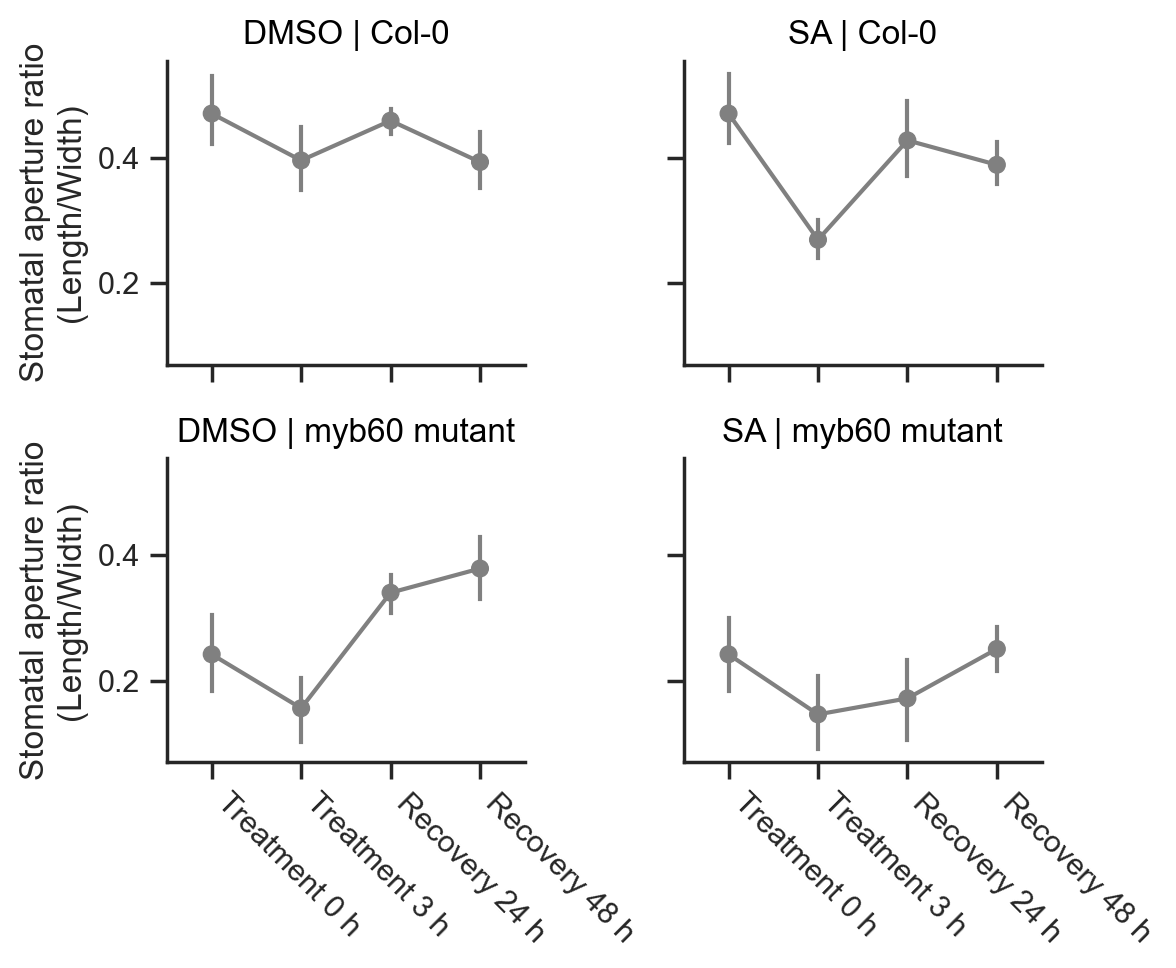

In [ ]:
fig = (
    so.Plot(df_stomata.query("biological_replicate == '1'"), x='time_point', y='aperture_ratio')
    .facet(col='treatment', row='genotype')
    .add(so.Range(), so.Est())
    .add(so.Dot(), so.Agg())
    .add(so.Line(), so.Agg())
    .layout(size=(6,5))
    .label(x='', y='Stomatal aperture ratio\n(Length/Width)')
).plot()._figure
for ax in fig.axes:
    for label in ax.get_xticklabels():
        label.set_rotation(-45)
        label.set_horizontalalignment('left')
fig

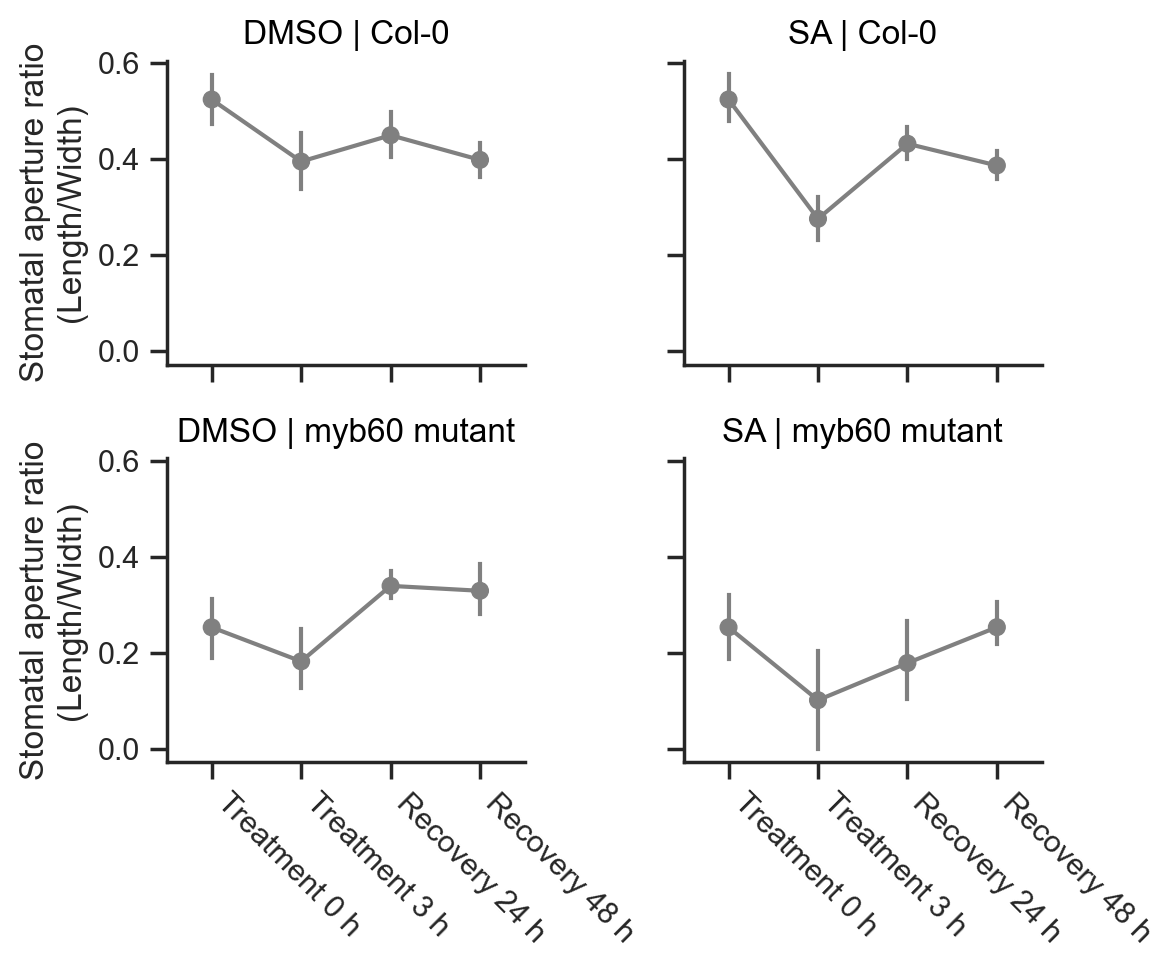

In [ ]:
fig = (
    so.Plot(df_stomata.query("biological_replicate == '2'"), x='time_point', y='aperture_ratio')
    .facet(col='treatment', row='genotype')
    .add(so.Range(), so.Est())
    .add(so.Dot(), so.Agg())
    .add(so.Line(), so.Agg())
    .layout(size=(6,5))
    .label(x='', y='Stomatal aperture ratio\n(Length/Width)')
).plot()._figure
for ax in fig.axes:
    for label in ax.get_xticklabels():
        label.set_rotation(-45)
        label.set_horizontalalignment('left')
fig